In [3]:
pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.8 MB 5.9 MB/s eta 0:00:01
   --------------- ------------------------ 1.0/2.8 MB 5.9 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
pip install matplotlib seaborn missingno ipykernel notebook

  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   -- ------------------------------------- 1.0/14.6 MB 6.0 MB/s eta 0:00:03
   ----- ---------------------------------- 2.1/14.6 MB 4.7 MB/s eta 0:00:03
   ------- -------------------------------- 2.9/14.6 MB 4.4 MB/s eta 0:00:03
   ---------- ----------------------------- 3.7/14.6 MB 4.3 MB/s eta 0:00:03
   ------------ --------------------------- 4.5/14.6 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.0/14.6 MB 3.9 MB/s eta 0:00:03
   ----------------- ---------------------- 6.3/14.6 MB 4.1 MB/s eta 0:00:03
   ------------------- --------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import psycopg2
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
import missingno as msno

In [5]:
conn = psycopg2.connect(
    host="localhost",
    database="idb",
    user="postgres",
    password="Sathdiv",
    port="5432"
)

In [6]:
cursor = conn.cursor()

In [8]:
df = pd.read_csv(
    r"C:\Users\Dell\Downloads\cleaned_Country-Series - Metadata (1).csv"
)

In [41]:
df.columns = df.columns.str.replace(" ", "_")

In [42]:
df = df.fillna("")

In [43]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS country_series (
    type TEXT,
    country_code VARCHAR(20),
    series_code VARCHAR(100),
    description TEXT,
    series_name TEXT
)
""")

In [44]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [45]:
print(df.columns)

Index(['type', 'country_code', 'series_code', 'description', 'country_name',
       'series_name'],
      dtype='str')


In [48]:
insert_query = """
INSERT INTO country_series (
    type,
    country_code,
    series_code,
    description,
    series_name
)
VALUES (%s, %s, %s, %s, %s)
"""

# Insert rows
for _, row in df.iterrows():

    cursor.execute(insert_query, (
        row['type'],
        row['country_code'],
        row['series_code'],
        row['description'],
        row['series_name']
    ))

# Save changes
conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [50]:
cursor.execute("SELECT * FROM country_series LIMIT 10")

In [51]:
rows = cursor.fetchall()

In [52]:
print("\nFirst 10 Rows:\n")
for row in rows:
    print(row)


First 10 Rows:

('Country-Series', 'AFG', 'BX.KLT.DINV.CD.DT', 'Data on Foreign Direct Investment are based on Balance of Payments reported by the International Monetary Fund. Unless otherwise specified in the specific years.', 'Foreign direct investment, net inflows in reporting economy (DRS, current US$)')
('Country-Series', 'AFG', 'SP.POP.TOTL', 'Data source: United Nations World Population Prospects', 'Population, total')
('Country-Series', 'AFG', 'DT.DOD.DECT.CD', 'Long-term public and publicly guaranteed, long-term private nonguaranteed and short-term debt data for 2024 are World Bank staff estimates. Short-term debt before 2015 is based on data from the BIS. Data include the effects of Paris Club debt restructuring agreements signed in 2010 and HIPC and MDRI debt relief. DSSI eligible and participating in 2020 and 2021.', 'External debt stocks, total (DOD, current US$)')
('Country-Series', 'AGO', 'DT.DOD.DECT.CD', 'Long-term public and publicly guaranteed debt data for 2024 are

In [45]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_CountryMetaData.csv")

In [54]:
cur = conn.cursor()


In [55]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [57]:
conn.rollback()

cur.execute("DROP TABLE IF EXISTS country_metadata")

conn.commit()

print("Old table deleted!")

Old table deleted!


In [58]:
cur.execute("""
CREATE TABLE country_metadata (
    id SERIAL PRIMARY KEY,
    country_code TEXT,
    long_name TEXT,
    income_group TEXT,
    region TEXT,
    lending_category TEXT,
    other_groups TEXT,
    currency_unit TEXT,
    latest_population_census TEXT,
    latest_household_survey TEXT,
    special_notes TEXT,
    national_accounts_base_year TEXT,
    national_accounts_reference_year TEXT,
    system_of_national_accounts TEXT,
    sna_price_valuation TEXT,
    ppp_survey_years TEXT,
    balance_of_payments_manual_in_use TEXT,
    external_debt_reporting_status TEXT,
    system_of_trade TEXT,
    government_accounting_concept TEXT,
    imf_data_dissemination_standard TEXT,
    source_of_most_recent_income_and_expenditure_data TEXT
)
""")

conn.commit()

print("New table created successfully!")

New table created successfully!


In [59]:
insert_query = """
INSERT INTO country_metadata (
    country_code,
    long_name,
    income_group,
    region,
    lending_category,
    other_groups,
    currency_unit,
    latest_population_census,
    latest_household_survey,
    special_notes,
    national_accounts_base_year,
    national_accounts_reference_year,
    system_of_national_accounts,
    sna_price_valuation,
    ppp_survey_years,
    balance_of_payments_manual_in_use,
    external_debt_reporting_status,
    system_of_trade,
    government_accounting_concept,
    imf_data_dissemination_standard,
    source_of_most_recent_income_and_expenditure_data
)
VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s
)
"""




In [60]:
conn.rollback()

for index, row in df.iterrows():
    try:
        cur.execute(insert_query, (
            row['country_code'],
            row['long_name'],
            row['income_group'],
            row['region'],
            row['lending_category'],
            row['other_groups'],
            row['currency_unit'],
            row['latest_population_census'],
            row['latest_household_survey'],
            row['special_notes'],
            row['national_accounts_base_year'],
            row['national_accounts_reference_year'],
            row['system_of_national_accounts'],
            row['sna_price_valuation'],
            row['ppp_survey_years'],
            row['balance_of_payments_manual_in_use'],
            row['external_debt_reporting_status'],
            row['system_of_trade'],
            row['government_accounting_concept'],
            row['imf_data_dissemination_standard'],
            row['source_of_most_recent_income_and_expenditure_data']
        ))

    except Exception as e:
        print(f"Error at row {index}")
        print(e)
        conn.rollback()
        break

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [61]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_FootNoteMetaData.csv")

In [62]:
conn.rollback()

cur.execute("DROP TABLE IF EXISTS footnote_metadata ")

conn.commit()

print("Old table deleted!")

Old table deleted!


In [63]:
cur.execute("""
CREATE TABLE IF NOT EXISTS footnote_metadata (
    id SERIAL PRIMARY KEY,
    type TEXT,
    country_code TEXT,
    series_code TEXT,
    time_code TEXT,
    description TEXT,
    country_name TEXT,
    series_name TEXT
)
""")

In [64]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['type', 'country_code', 'series_code', 'time_code', 'description', 'country_name', 'series_name']


In [65]:
insert_query = """
INSERT INTO footnote_metadata (
    type,
    country_code,
    series_code,
    time_code,
    description,
    country_name,
    series_name
)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""
for _, row in df.iterrows():
    cur.execute(insert_query, (
        row['type'],
        row['country_code'],
        row['series_code'],
        row['time_code'],
        row['description'],
        row['country_name'],
        row['series_name']
    ))

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [11]:
cur = conn.cursor()

In [25]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_SeriesMetaData.csv")

In [26]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [27]:
print(df.columns.tolist())

['series_code', 'indicator_name', 'short_definition', 'long_definition', 'source', 'topic', 'dataset', 'periodicity', 'aggregation_method']


In [28]:
cur.execute("""
CREATE TABLE IF NOT EXISTS series_metadata (
    id SERIAL PRIMARY KEY,
    series_code TEXT,
    indicator_name TEXT,
    short_definition TEXT,
    long_definition TEXT,
    source TEXT,
    topic TEXT,
    dataset TEXT,
    periodicity TEXT,
    aggregation_method TEXT
)
""")

conn.commit()

print("Table created successfully!")

Table created successfully!


In [29]:
insert_query = """
INSERT INTO series_metadata (
    series_code,
    indicator_name,
    short_definition,
    long_definition,
    source,
    topic,
    dataset,
    periodicity,
    aggregation_method
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

In [30]:
for _, row in df.iterrows():
    cur.execute(insert_query, (
        row['series_code'],
        row['indicator_name'],
        row['short_definition'],
        row['long_definition'],
        row['source'],
        row['topic'],
        row['dataset'],
        row['periodicity'],
        row['aggregation_method']
    ))

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [31]:
cur.execute("""
CREATE TABLE IF NOT EXISTS country_debt_data (
    id SERIAL PRIMARY KEY,
    country_name TEXT,
    country_code TEXT,
    counterpart_area_name TEXT,
    counterpart_area_code TEXT,
    series_name TEXT,
    series_code TEXT,
    year INT,
    value NUMERIC
)
""")

conn.commit()

print("Table created successfully!")

Table created successfully!


In [7]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_ALLCountries_Data (2).csv")

In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [9]:
print(df.columns.tolist())

['country_name', 'country_code', 'counterpart_area_name', 'counterpart_area_code', 'series_name', 'series_code', 'year', 'value']


In [18]:
insert_query = """
INSERT INTO country_debt_data (
    country_name,
    country_code,
    counterpart_area_name,
    counterpart_area_code,
    series_name,
    series_code,
    year,
    value
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
"""

In [19]:
df

,country_name,country_code,counterpart_area_name,counterpart_area_code,series_name,series_code,year,value
0,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,9.046966e+06
1,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,9.046966e+06
2,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,9.046966e+06
3,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.DPPG,2000,9.046966e+06
4,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.OFFT,2000,9.046966e+06
...,...,...,...,...,...,...,...,...
1284360,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, total (UND, current...",DT.UND.DPPG.CD,2024,6.944589e+08
1284361,Zimbabwe,ZWE,World,WLD,"Use of IMF credit and SDR allocations (DOD, cu...",DT.DOD.DIMF.CD,2024,1.325023e+09
1284362,Zimbabwe,ZWE,World,WLD,"Use of IMF credit and SDR allocations (DOD, cu...",DT.DOD.DIMF.CD,2024,3.286379e+07
1284363,Data from database: International Debt Statistics,ZWE,World,WLD,"Use of IMF credit and SDR allocations (DOD, cu...",DT.DOD.DIMF.CD,2024,3.286379e+07


In [20]:
df.year

0          2000
1          2000
2          2000
3          2000
4          2000
           ... 
1284360    2024
1284361    2024
1284362    2024
1284363    2024
1284364    2024
Name: year, Length: 1284365, dtype: int64

In [21]:
data = df.values.tolist()


In [22]:
data

[['Afghanistan',
  'AFG       ',
  'World',
  'WLD',
  'Average grace period on new external debt commitments (years)',
  'DT.GPA.DPPG',
  2000,
  9046966.25],
 ['Afghanistan',
  'AFG       ',
  'World',
  'WLD',
  'Average grace period on new external debt commitments, official (years)',
  'DT.GPA.OFFT',
  2000,
  9046966.25],
 ['Afghanistan',
  'AFG       ',
  'World',
  'WLD',
  'Average grace period on new external debt commitments, private (years)',
  'DT.GPA.PRVT',
  2000,
  9046966.25],
 ['Afghanistan',
  'AFG       ',
  'World',
  'WLD',
  'Average grant element on new external debt commitments (%)',
  'DT.GRE.DPPG',
  2000,
  9046966.25],
 ['Afghanistan',
  'AFG       ',
  'World',
  'WLD',
  'Average grant element on new external debt commitments, official (%)',
  'DT.GRE.OFFT',
  2000,
  9046966.25],
 ['Afghanistan',
  'AFG       ',
  'World',
  'WLD',
  'Average grant element on new external debt commitments, private (%)',
  'DT.GRE.PRVT',
  2000,
  9046966.25],
 ['Afghanis

In [23]:
len(df)

1284365

In [24]:
len(data)

1284365

In [25]:
cursor.executemany(insert_query,data)
conn.commit()

EDA FOR 1ST DATASET

In [85]:
print("\nFirst 5 Rows:\n")
print(df.head())


First 5 Rows:

  country_name country_code counterpart_area_name counterpart_area_code  \
0  Afghanistan   AFG                        World                   WLD   
1  Afghanistan   AFG                        World                   WLD   
2  Afghanistan   AFG                        World                   WLD   
3  Afghanistan   AFG                        World                   WLD   
4  Afghanistan   AFG                        World                   WLD   

                                         series_name  series_code  year  \
0  Average grace period on new external debt comm...  DT.GPA.DPPG  2000   
1  Average grace period on new external debt comm...  DT.GPA.OFFT  2000   
2  Average grace period on new external debt comm...  DT.GPA.PRVT  2000   
3  Average grant element on new external debt com...  DT.GRE.DPPG  2000   
4  Average grant element on new external debt com...  DT.GRE.OFFT  2000   

        value  
0  9046966.25  
1  9046966.25  
2  9046966.25  
3  9046966.25  
4 

In [86]:
print("\nDataset Shape:\n")
print(df.shape)


Dataset Shape:

(1784875, 8)


In [87]:
print("\nColumn Names:\n")
print(df.columns)


Column Names:

Index(['country_name', 'country_code', 'counterpart_area_name',
       'counterpart_area_code', 'series_name', 'series_code', 'year', 'value'],
      dtype='str')


In [88]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 1784875 entries, 0 to 1784874
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   country_name           str    
 1   country_code           str    
 2   counterpart_area_name  str    
 3   counterpart_area_code  str    
 4   series_name            str    
 5   series_code            str    
 6   year                   int64  
 7   value                  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 108.9 MB
None


In [89]:

print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

country_name             0
country_code             0
counterpart_area_name    0
counterpart_area_code    0
series_name              0
series_code              0
year                     0
value                    0
dtype: int64


In [95]:
print("\nDuplicate Rows:\n")
print(df.duplicated().sum())



Duplicate Rows:

0


In [94]:
df = df.drop_duplicates()

In [96]:
print("\nDescriptive Statistics:\n")
print(df.describe(include='all'))


Descriptive Statistics:

               country_name country_code counterpart_area_name  \
count               1784867      1784867               1784867   
unique                  136          134                     1   
top     Low & middle income   LMY                        World   
freq                  17419        17419               1784867   
mean                    NaN          NaN                   NaN   
std                     NaN          NaN                   NaN   
min                     NaN          NaN                   NaN   
25%                     NaN          NaN                   NaN   
50%                     NaN          NaN                   NaN   
75%                     NaN          NaN                   NaN   
max                     NaN          NaN                   NaN   

       counterpart_area_code  \
count                1784867   
unique                     1   
top                      WLD   
freq                 1784867   
mean                 

In [97]:
for col in df.columns:
    print(f"\nUnique values in {col}: {df[col].nunique()}")


Unique values in country_name: 136

Unique values in country_code: 134

Unique values in counterpart_area_name: 1

Unique values in counterpart_area_code: 1

Unique values in series_name: 576

Unique values in series_code: 576

Unique values in year: 33

Unique values in value: 649557


In [98]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


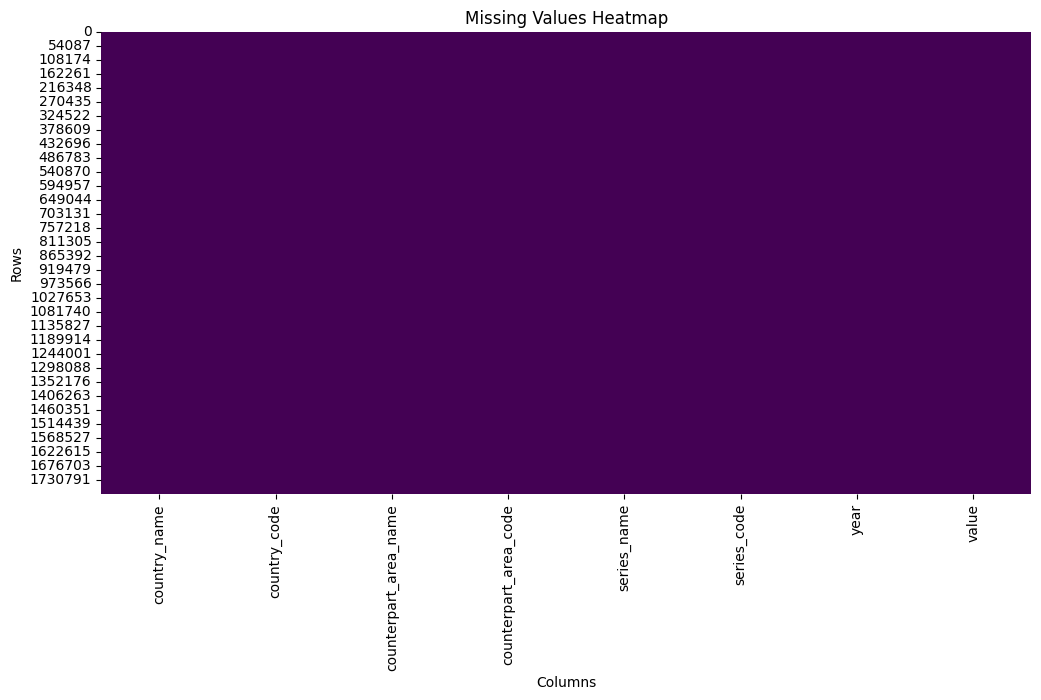

In [99]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [101]:
print("\n" + "─" * 40)
print("SERIES COVERAGE PER COUNTRY (pivot sample)")
print("─" * 40)
pivot = df.pivot_table(
    index="country_name", columns="series_code",
    aggfunc="size", fill_value=0
)
# Short column names for display
pivot.columns = [c.split(".")[-1] for c in pivot.columns]
coverage = pivot.gt(0).sum(axis=1)
print(f"Countries with 3 main series : {(coverage >= 3).sum()}")
print(f"Countries with 1 series only : {(coverage == 1).sum()}")
print("\nCoverage count distribution:")
print(coverage.value_counts().sort_index().to_string())



────────────────────────────────────────
SERIES COVERAGE PER COUNTRY (pivot sample)
────────────────────────────────────────
Countries with 3 main series : 134
Countries with 1 series only : 2

Coverage count distribution:
1      2
261    1
277    1
278    1
297    1
338    1
354    2
357    1
368    1
371    1
381    1
382    1
389    1
391    1
392    1
395    1
396    1
405    2
406    1
407    1
409    1
412    2
413    3
418    2
423    1
424    1
426    1
431    1
433    1
434    2
435    1
436    1
438    2
439    1
441    1
443    1
444    2
445    2
446    2
449    3
451    1
452    1
455    1
456    2
459    1
460    1
461    1
462    1
463    1
465    2
466    2
467    1
468    1
469    2
475    1
476    2
478    1
480    1
481    1
488    1
490    2
491    1
492    1
493    2
495    1
498    1
499    1
500    1
501    1
503    2
505    1
506    1
509    1
510    1
512    1
515    1
518    2
520    1
522    1
523    1
524    1
528    2
529    2
530    1
533    1
534    1
53

In [117]:
df.columns

Index(['country_name', 'country_code', 'counterpart-area_name',
       'counterpart-area_code', 'series_name', 'series_code', 'year', 'value'],
      dtype='str')

In [119]:
# PIE CHART FOR TYPE COLUMN
# ---------------------------------

if 'type' in df.columns:

    plt.figure(figsize=(7,7))

    df['type'].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )

    plt.title("Type Distribution")
    plt.ylabel("")

    plt.show()

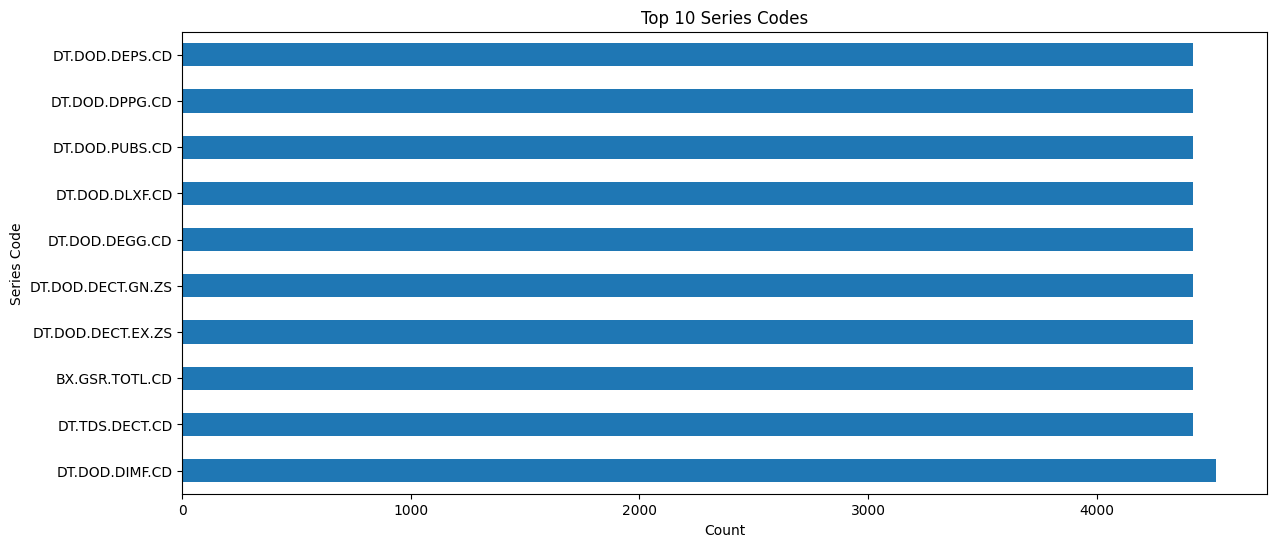

In [120]:
# SERIES CODE COUNT GRAPH
# ---------------------------------

if 'series_code' in df.columns:

    plt.figure(figsize=(14,6))

    df['series_code'].value_counts().head(10).plot(
        kind='barh'
    )

    plt.title("Top 10 Series Codes")
    plt.xlabel("Count")
    plt.ylabel("Series Code")

    plt.show()

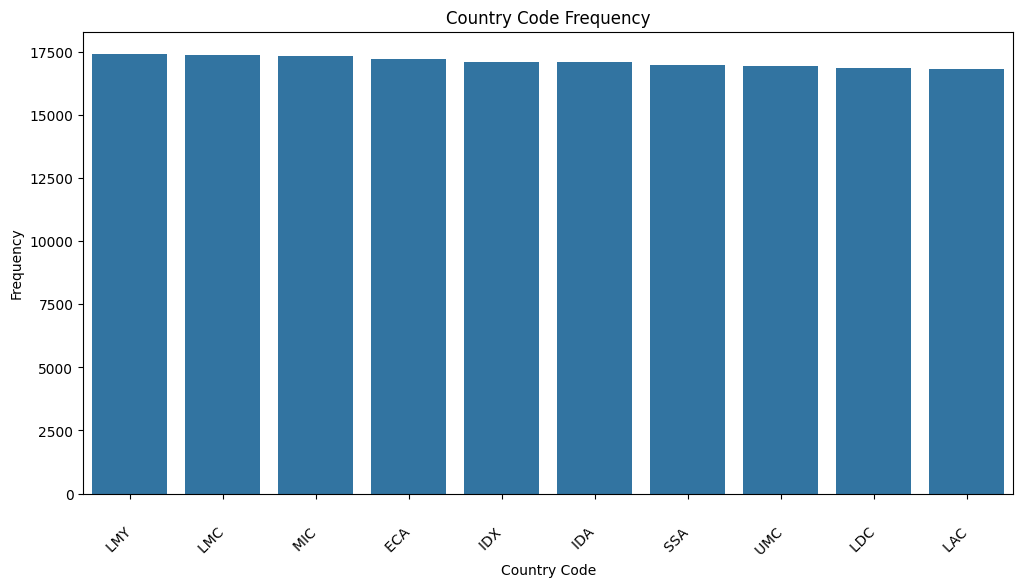

Graphs and Heatmaps Generated Successfully


In [109]:
# COUNTPLOT FOR COUNTRY CODE
# ---------------------------------

if 'country_code' in df.columns:

    plt.figure(figsize=(12,6))

    sns.countplot(
        x=df['country_code'],
        order=df['country_code'].value_counts().head(10).index
    )

    plt.title("Country Code Frequency")
    plt.xlabel("Country Code")
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)

    plt.show()

print("Graphs and Heatmaps Generated Successfully")

In [110]:
# SELECT NUMERIC COLUMNS
# ---------------------------------

numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Numeric Columns:\n")
print(numeric_df.columns)

Numeric Columns:

Index(['year', 'value'], dtype='str')


In [111]:
# CORRELATION MATRIX
# ---------------------------------

corr = numeric_df.corr()

print("\nCorrelation Matrix:\n")
print(corr)


Correlation Matrix:

           year     value
year   1.000000 -0.003112
value -0.003112  1.000000



Correlation Matrix:

           year     value
year   1.000000 -0.003112
value -0.003112  1.000000


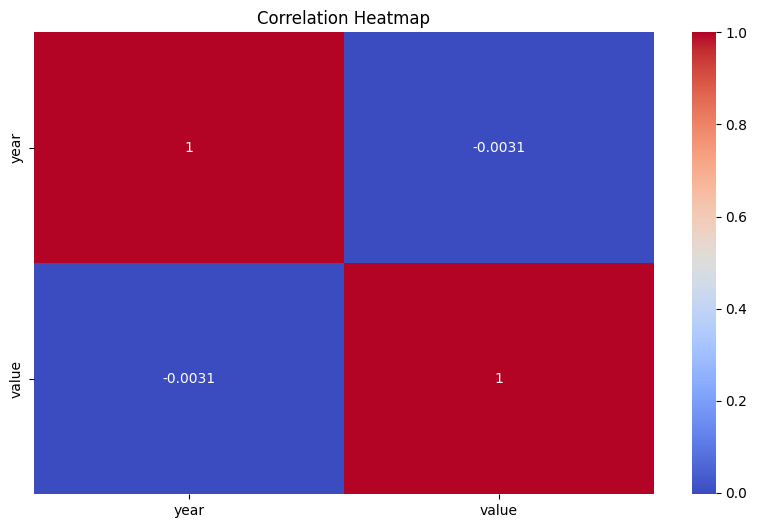

In [112]:
# CHECK IF NUMERIC COLUMNS EXIST
# ---------------------------------

if numeric_df.shape[1] > 0:

    corr = numeric_df.corr()

    print("\nCorrelation Matrix:\n")
    print(corr)

    # Heatmap
    plt.figure(figsize=(10,6))

    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm'
    )

    plt.title("Correlation Heatmap")

    plt.show()

else:
    print("\nNo numeric columns found.")
    print("Correlation heatmap cannot be generated.")

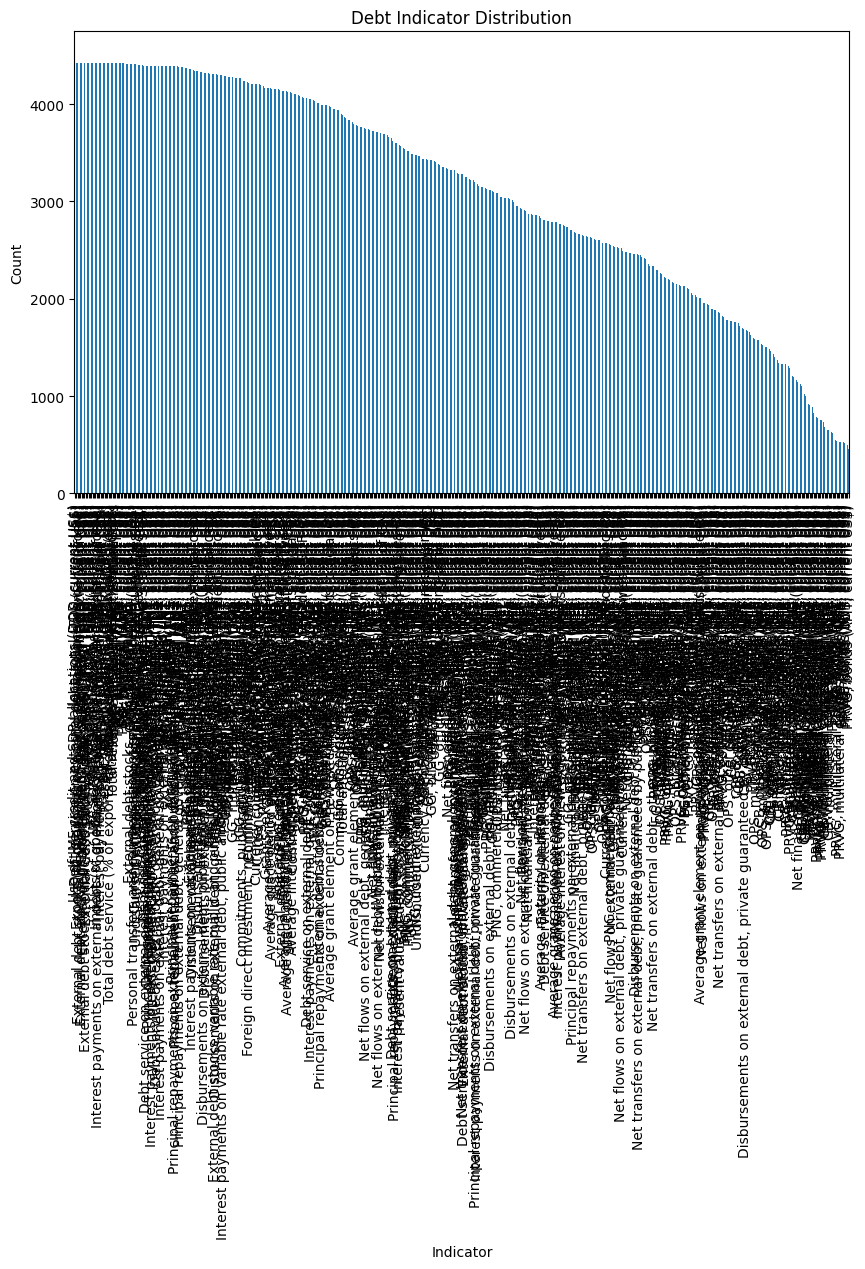

In [113]:
# COUNT OF INDICATORS
# -------------------------------
plt.figure(figsize=(10,6))

df['series_name'].value_counts().plot(
    kind='bar'
)

plt.title("Debt Indicator Distribution")
plt.xlabel("Indicator")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


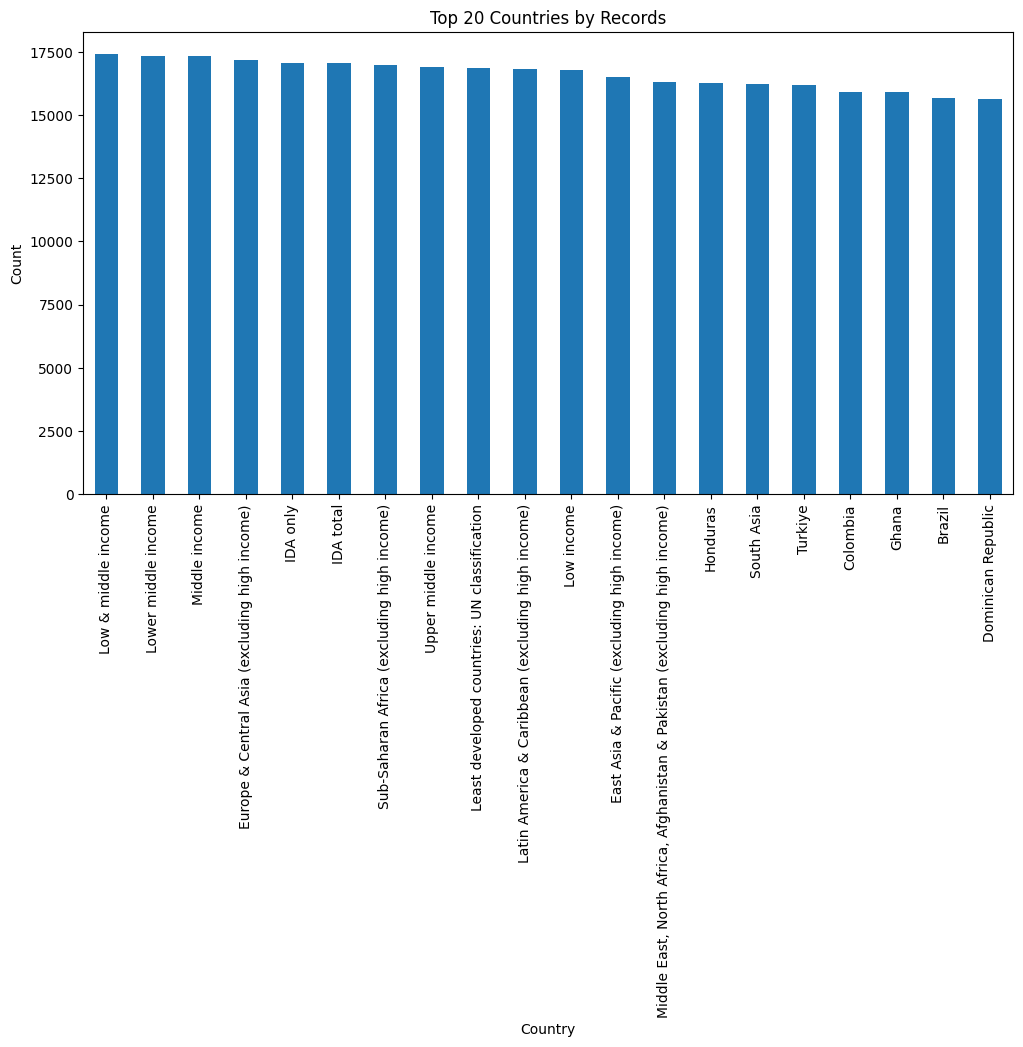

In [114]:
# COUNTRY DISTRIBUTION
# -------------------------------
plt.figure(figsize=(12,6))

df['country_name'].value_counts().head(20).plot(
    kind='bar'
)

plt.title("Top 20 Countries by Records")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


In [115]:
# FILTER DEBT RELATED RECORDS
# -------------------------------
debt_df = df[
    df['series_name'].str.contains('debt', case=False, na=False)
]

print(debt_df.head())

  country_name country_code counterpart-area_name counterpart-area_code  \
0  Afghanistan   AFG                        World                   WLD   
1  Afghanistan   AFG                        World                   WLD   
2  Afghanistan   AFG                        World                   WLD   
3  Afghanistan   AFG                        World                   WLD   
4  Afghanistan   AFG                        World                   WLD   

                                                               series_name  \
0            Average grace period on new external debt commitments (years)   
1  Average grace period on new external debt commitments, official (years)   
2   Average grace period on new external debt commitments, private (years)   
3               Average grant element on new external debt commitments (%)   
4     Average grant element on new external debt commitments, official (%)   

   series_code  year       value  
0  DT.GPA.DPPG  2000  9046966.25  
1  DT.GPA.

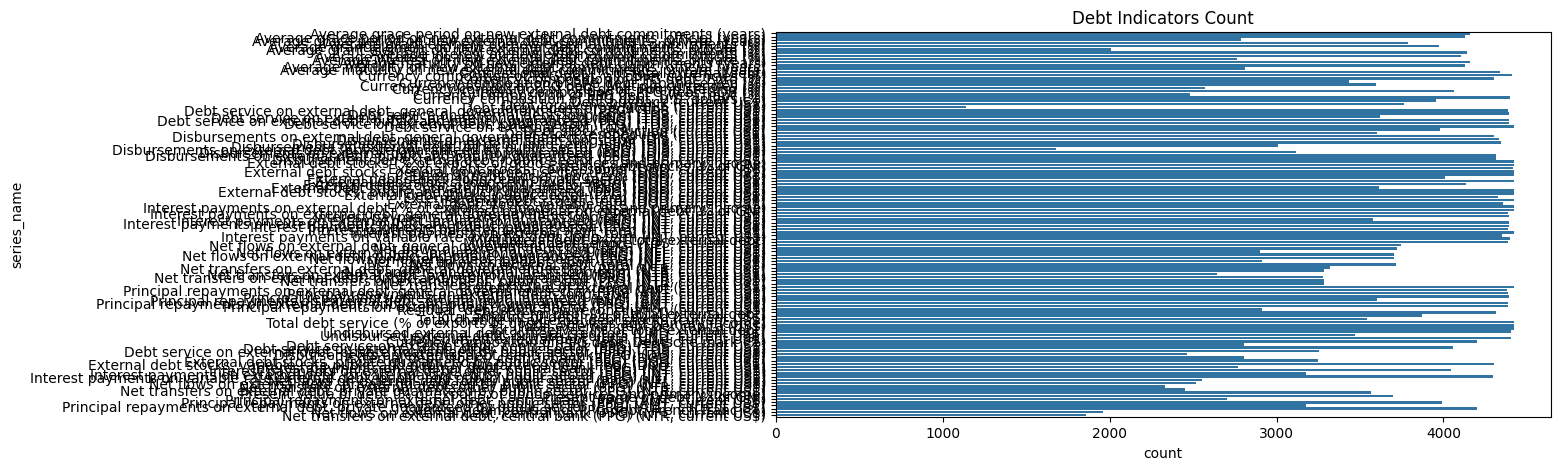

In [121]:
# DEBT INDICATOR COUNTS
# -------------------------------
plt.figure(figsize=(10,5))

sns.countplot(
    y='series_name',
    data=debt_df
)

plt.title("Debt Indicators Count")
plt.show()

In [122]:
# FILTER DEBT RELATED RECORDS
debt_data = df[
    df['series_name'].str.contains('debt', case=False, na=False)
]

print(debt_data.head())

  country_name country_code counterpart-area_name counterpart-area_code  \
0  Afghanistan   AFG                        World                   WLD   
1  Afghanistan   AFG                        World                   WLD   
2  Afghanistan   AFG                        World                   WLD   
3  Afghanistan   AFG                        World                   WLD   
4  Afghanistan   AFG                        World                   WLD   

                                                               series_name  \
0            Average grace period on new external debt commitments (years)   
1  Average grace period on new external debt commitments, official (years)   
2   Average grace period on new external debt commitments, private (years)   
3               Average grant element on new external debt commitments (%)   
4     Average grant element on new external debt commitments, official (%)   

   series_code  year       value  
0  DT.GPA.DPPG  2000  9046966.25  
1  DT.GPA.

EDA DATA SET -2

In [12]:
print(df.head())

  country_name country_code counterpart-area_name counterpart-area_code  \
0  Afghanistan   AFG                        World                   WLD   
1  Afghanistan   AFG                        World                   WLD   
2  Afghanistan   AFG                        World                   WLD   
3  Afghanistan   AFG                        World                   WLD   
4  Afghanistan   AFG                        World                   WLD   

                                         series_name  series_code  year  \
0  Average grace period on new external debt comm...  DT.GPA.DPPG  2000   
1  Average grace period on new external debt comm...  DT.GPA.OFFT  2000   
2  Average grace period on new external debt comm...  DT.GPA.PRVT  2000   
3  Average grant element on new external debt com...  DT.GRE.DPPG  2000   
4  Average grant element on new external debt com...  DT.GRE.OFFT  2000   

        value  
0  9046966.25  
1  9046966.25  
2  9046966.25  
3  9046966.25  
4  9046966.25  


In [13]:
print(df.shape)

(1784875, 8)


In [14]:
print(df.columns)

Index(['country_name', 'country_code', 'counterpart-area_name',
       'counterpart-area_code', 'series_name', 'series_code', 'year', 'value'],
      dtype='str')


In [15]:
df.info

<bound method DataFrame.info of                                               country_name country_code  \
0                                              Afghanistan   AFG          
1                                              Afghanistan   AFG          
2                                              Afghanistan   AFG          
3                                              Afghanistan   AFG          
4                                              Afghanistan   AFG          
...                                                    ...          ...   
1784870                                           Zimbabwe   ZWE          
1784871                                           Zimbabwe   ZWE          
1784872                                           Zimbabwe   ZWE          
1784873  Data from database: International Debt Statistics   ZWE          
1784874                           Last Updated: 12/03/2025   ZWE          

        counterpart-area_name counterpart-area_code  \
0           

In [16]:
print(df.isnull().sum())

country_name             0
country_code             0
counterpart-area_name    0
counterpart-area_code    0
series_name              0
series_code              0
year                     0
value                    0
dtype: int64


In [20]:
df = df.drop_duplicates()

In [21]:
print(df.duplicated().sum())

0


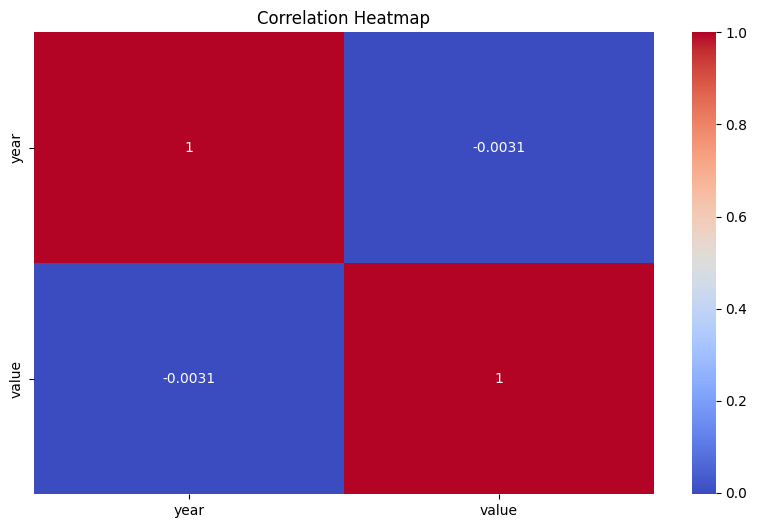

In [22]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

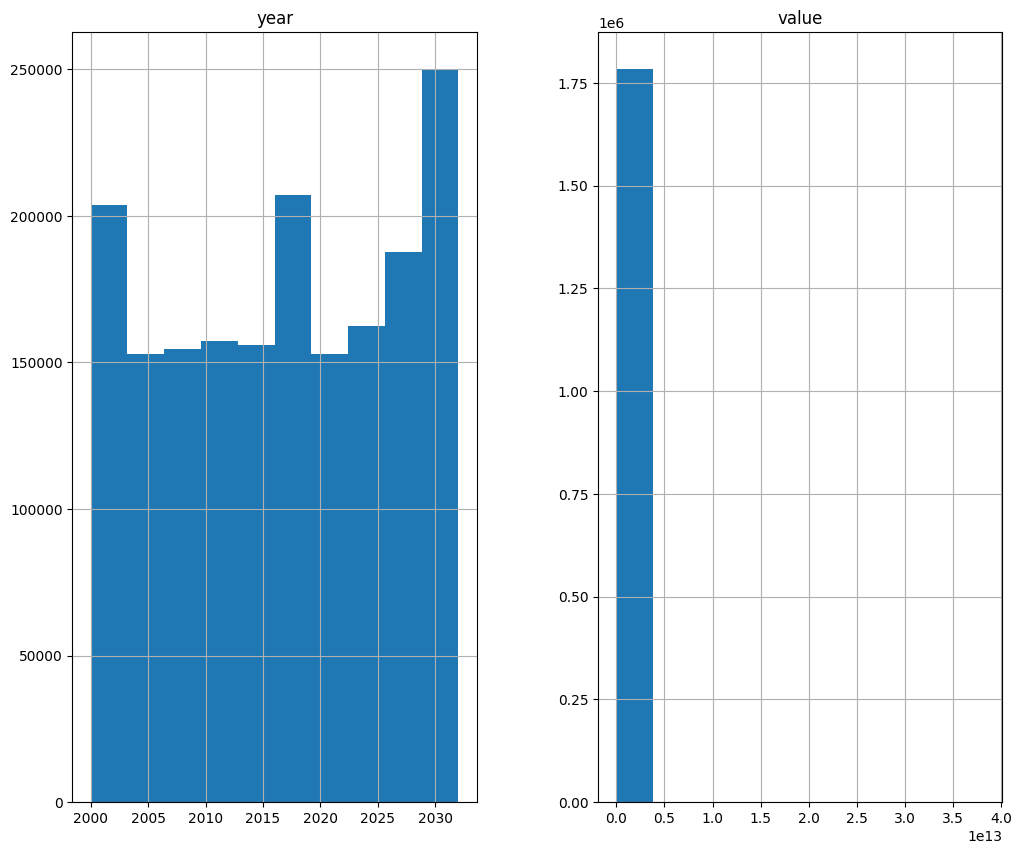

In [23]:
df.hist(figsize=(12,10))
plt.show()

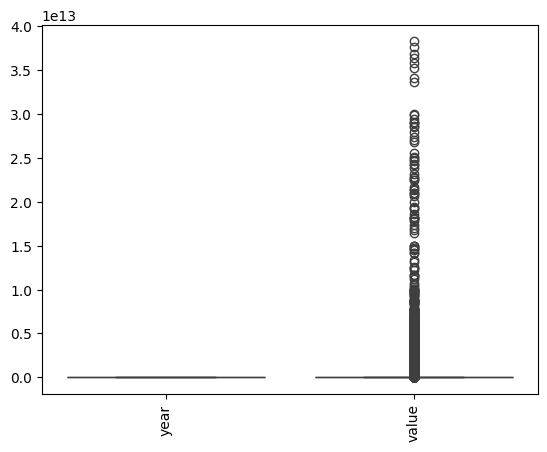

In [24]:
sns.boxplot(data=numeric_df)

plt.xticks(rotation=90)
plt.show()

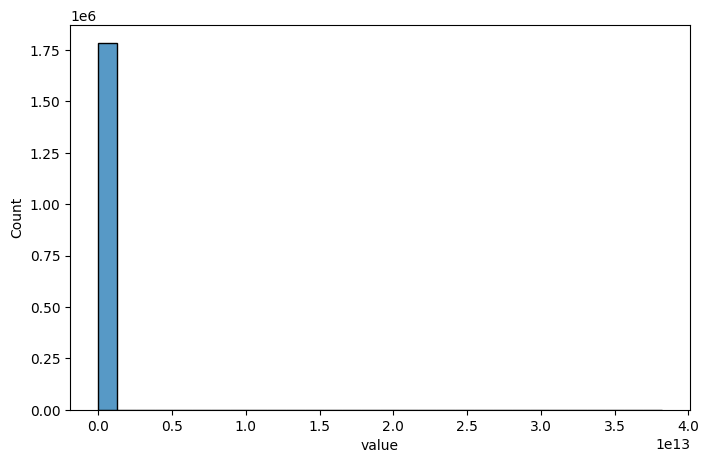

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['value'], bins=30)

plt.show()

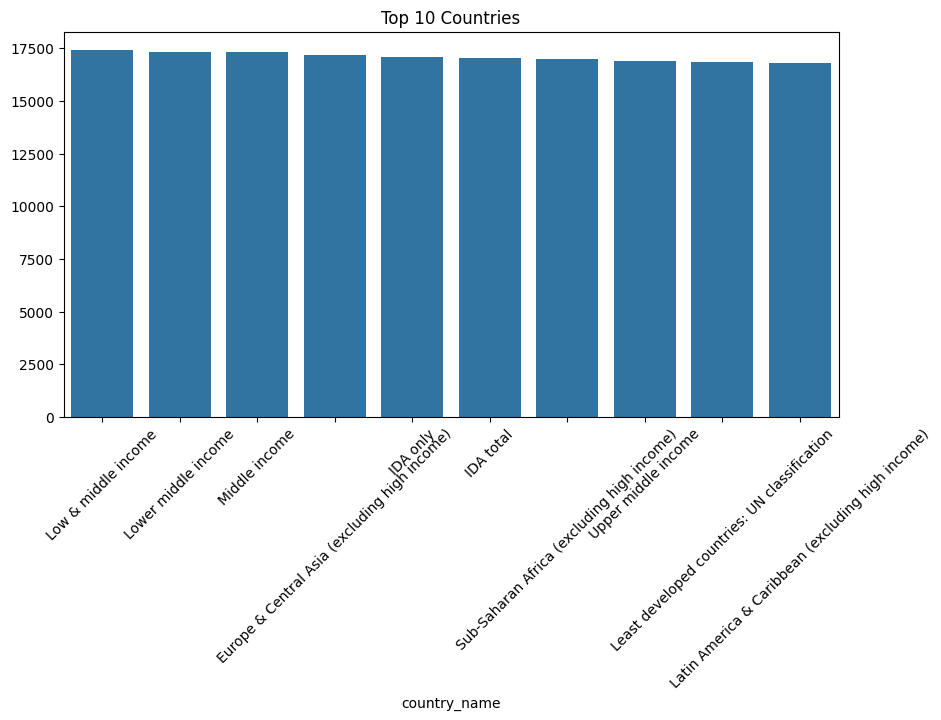

In [26]:
top10 = df['country_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries")

plt.show()

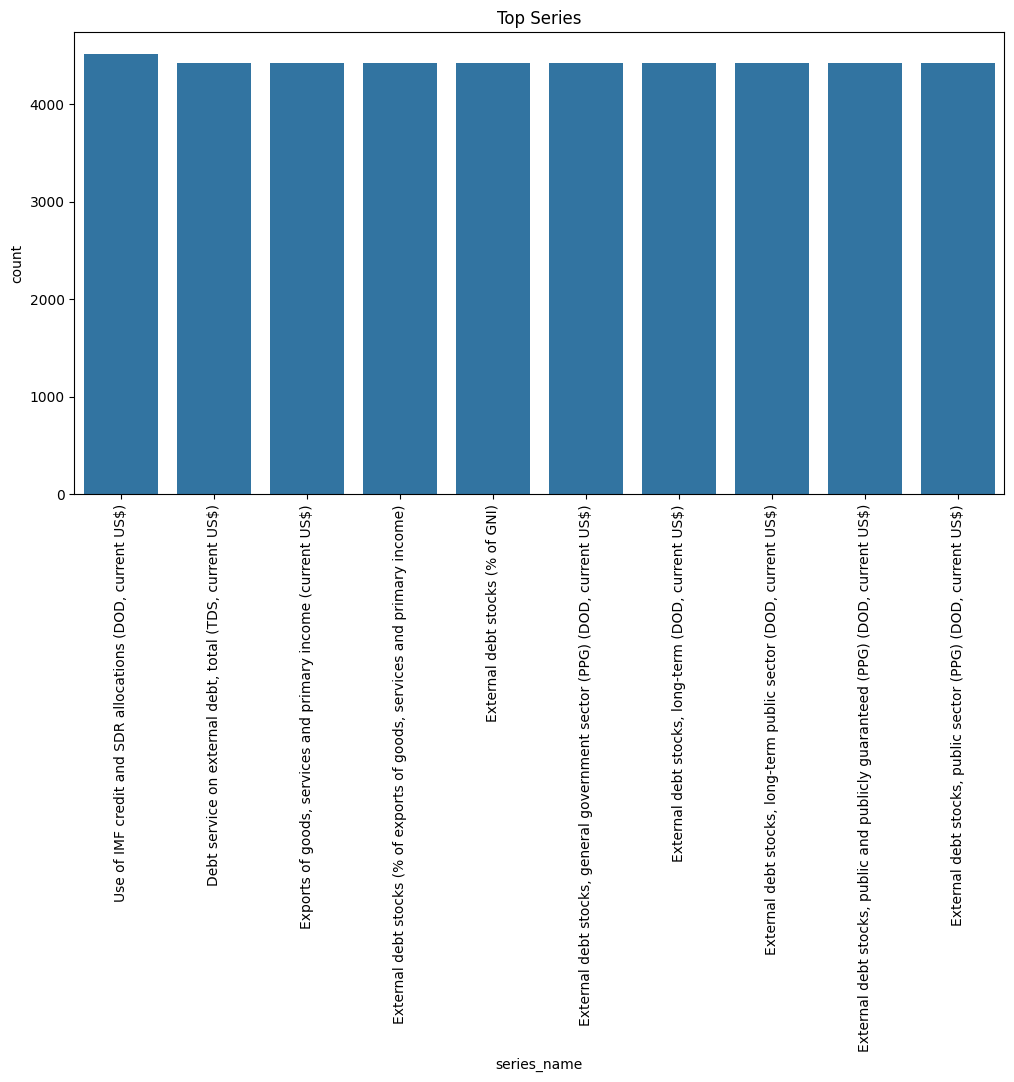

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='series_name',
    data=df,
    order=df['series_name'].value_counts().index[:10]
)

plt.xticks(rotation=90)

plt.title("Top Series")

plt.show()

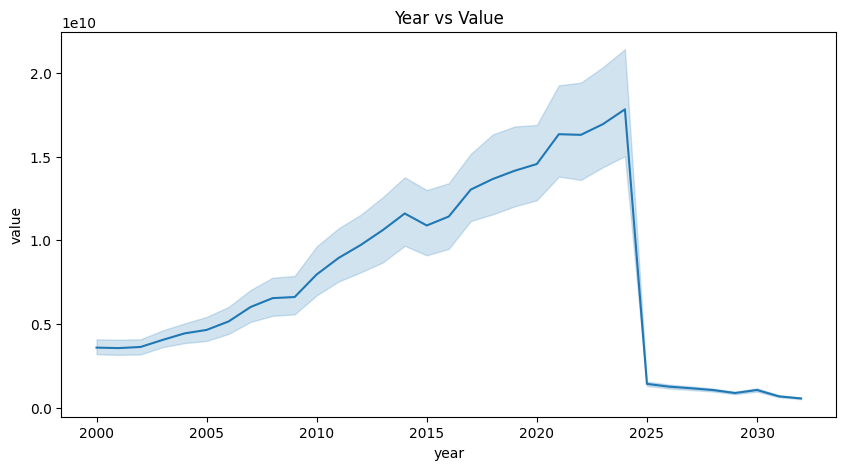

In [28]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x='year',
    y='value',
    data=df
)

plt.title("Year vs Value")

plt.show()

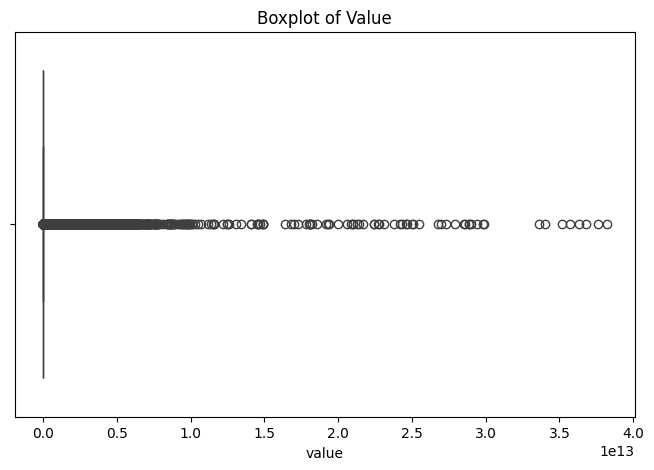

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['value'])

plt.title("Boxplot of Value")

plt.show()

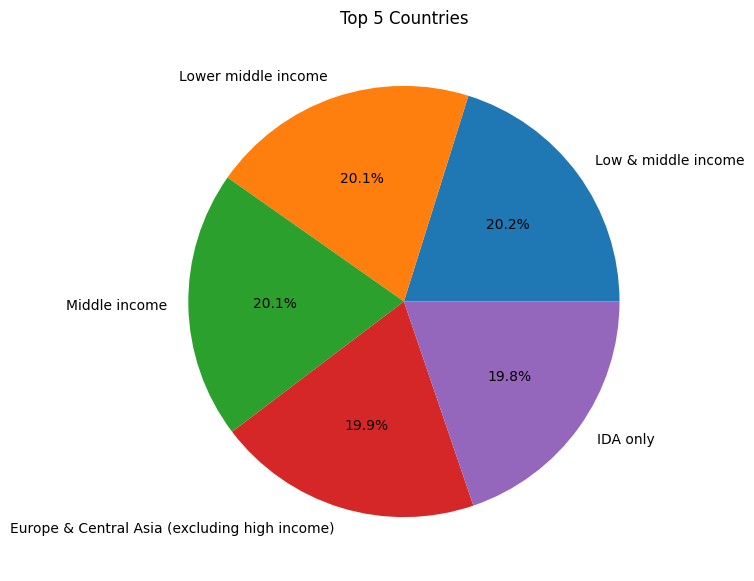

In [31]:
top5 = df['country_name'].value_counts().head(5)

plt.figure(figsize=(7,7))

top5.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Top 5 Countries")

plt.show()

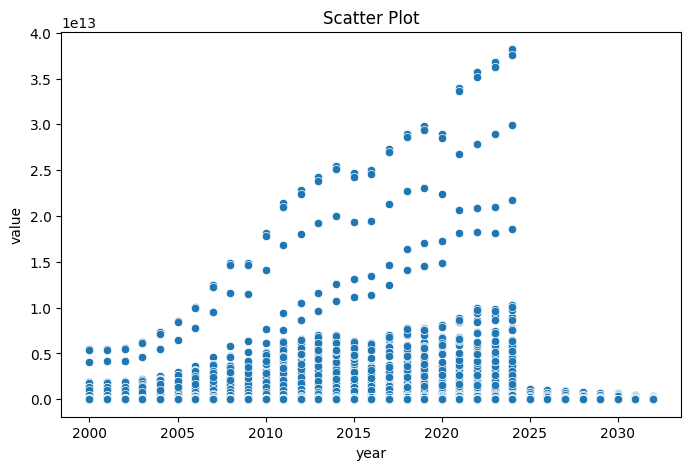

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='year',
    y='value',
    data=df
)

plt.title("Scatter Plot")

plt.show()

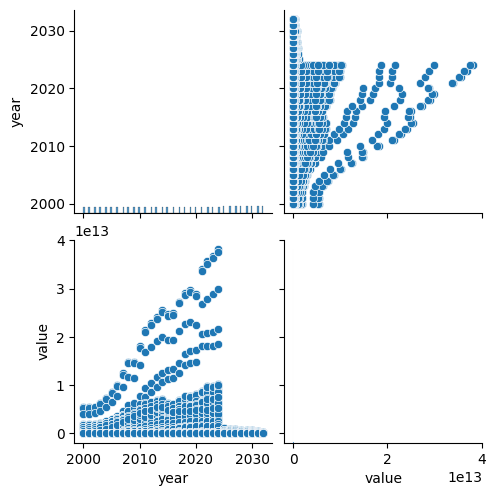

In [33]:
sns.pairplot(df.select_dtypes(include='number'))

plt.show()

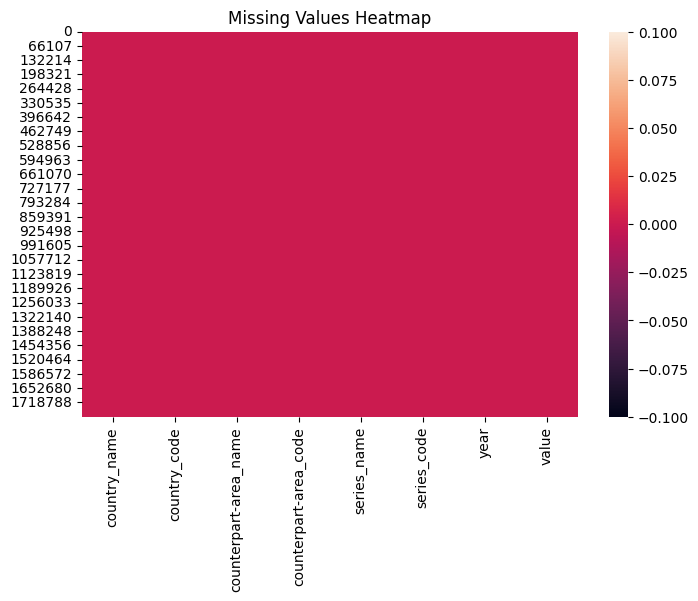

In [34]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull())

plt.title("Missing Values Heatmap")

plt.show()

In [35]:
country_debt = df.groupby('country_name')['value'].sum().sort_values(ascending=False)

print(country_debt.head(10))

country_name
Low & middle income                                  2.454088e+15
Middle income                                        2.383970e+15
Upper middle income                                  1.749750e+15
East Asia & Pacific (excluding high income)          9.131120e+14
Lower middle income                                  6.378972e+14
China                                                6.302831e+14
Latin America & Caribbean (excluding high income)    5.998006e+14
IDA total                                            3.104528e+14
Europe & Central Asia (excluding high income)        2.721676e+14
South Asia                                           2.448086e+14
Name: value, dtype: float64


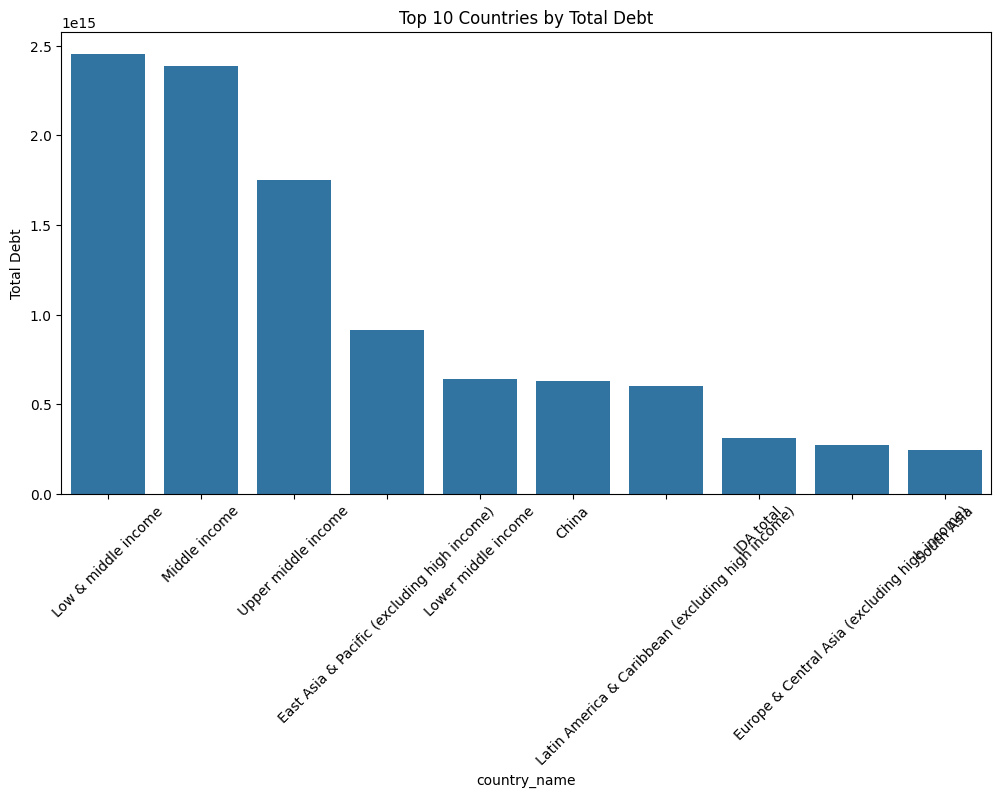

In [36]:
top10 = country_debt.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Total Debt")

plt.ylabel("Total Debt")

plt.show()

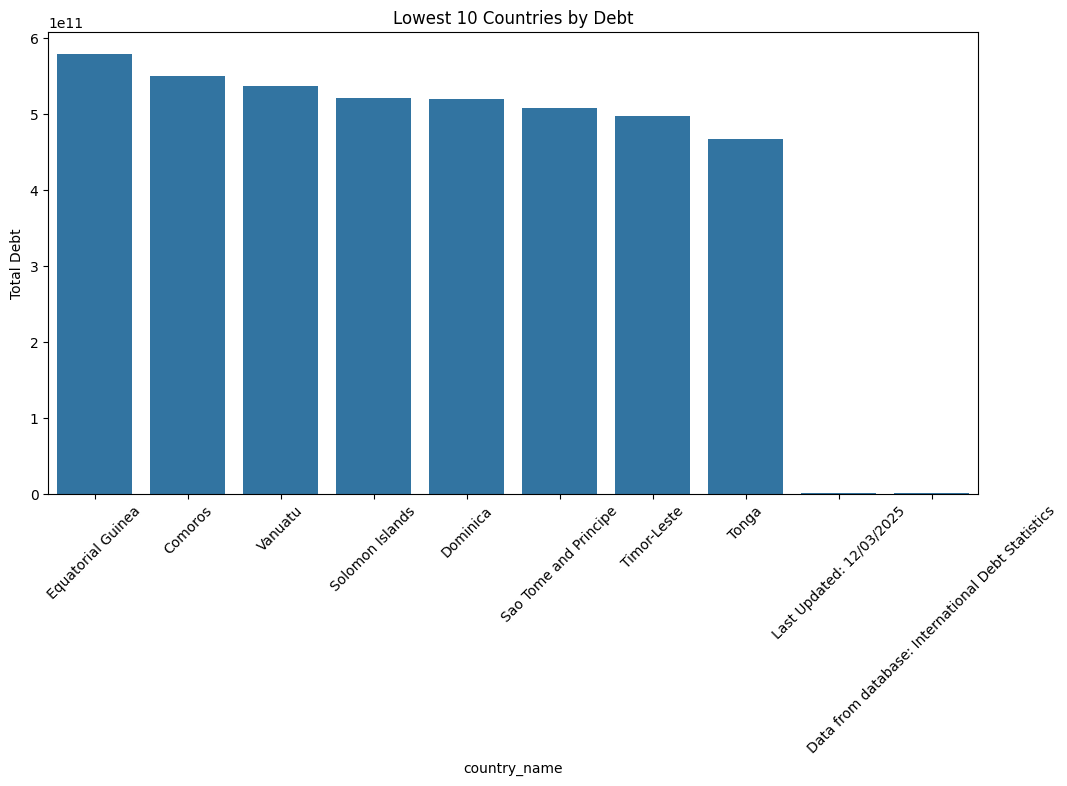

In [37]:
lowest10 = country_debt.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=lowest10.index,
    y=lowest10.values
)

plt.xticks(rotation=45)

plt.title("Lowest 10 Countries by Debt")

plt.ylabel("Total Debt")

plt.show()

In [38]:
print(df['series_name'].unique())

<StringArray>
[          'Average grace period on new external debt commitments (years)',
 'Average grace period on new external debt commitments, official (years)',
  'Average grace period on new external debt commitments, private (years)',
              'Average grant element on new external debt commitments (%)',
    'Average grant element on new external debt commitments, official (%)',
     'Average grant element on new external debt commitments, private (%)',
                   'Average interest on new external debt commitments (%)',
         'Average interest on new external debt commitments, official (%)',
          'Average interest on new external debt commitments, private (%)',
               'Average maturity on new external debt commitments (years)',
 ...
                          'PS, other private creditors (NTR, current US$)',
                                 'CB, commercial banks (NFL, current US$)',
                                 'CB, commercial banks (NTR, current 

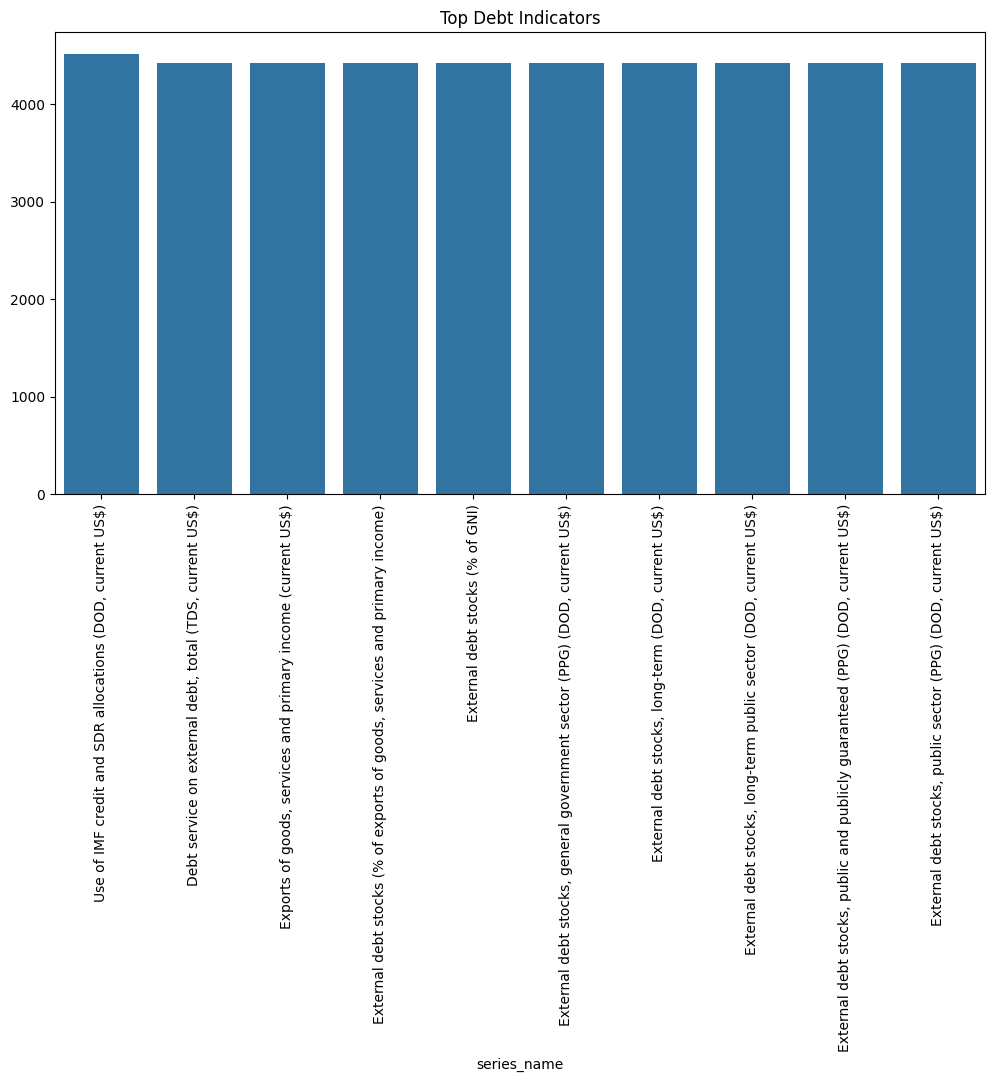

In [39]:
indicator_count = df['series_name'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=indicator_count.index,
    y=indicator_count.values
)

plt.xticks(rotation=90)

plt.title("Top Debt Indicators")

plt.show()

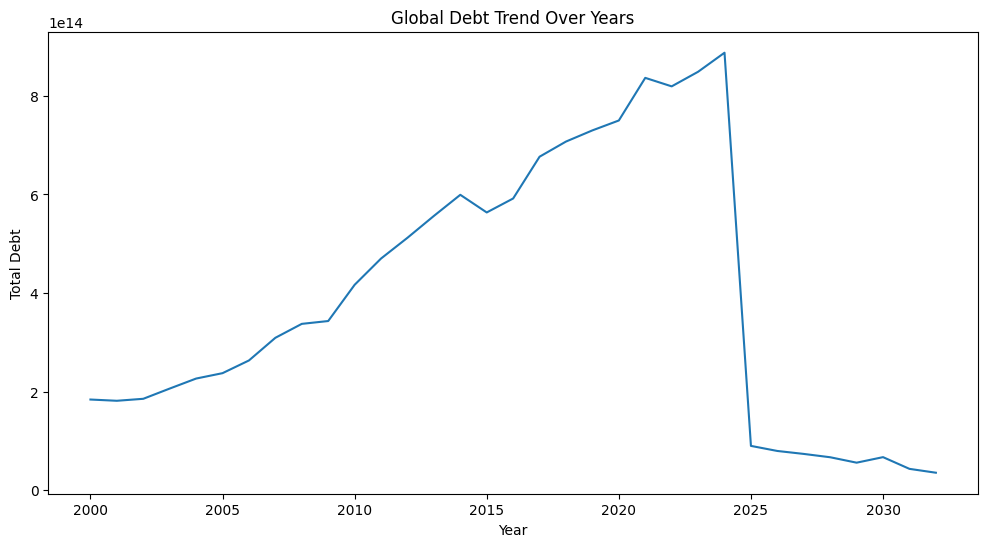

In [40]:
yearly_debt = df.groupby('year')['value'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=yearly_debt.index,
    y=yearly_debt.values
)

plt.title("Global Debt Trend Over Years")

plt.xlabel("Year")

plt.ylabel("Total Debt")

plt.show()

In [41]:
pivot_data = df.pivot_table(
    values='value',
    index='country_name',
    columns='series_name',
    aggfunc='mean'
)

print(pivot_data.head())

series_name   Average grace period on new external debt commitments (years)  \
country_name                                                                  
Afghanistan                                        5.263535e+07               
Albania                                            3.188717e+07               
Algeria                                            5.261382e+07               
Angola                                             3.188716e+07               
Argentina                                          3.188717e+07               

series_name   Average grace period on new external debt commitments, official (years)  \
country_name                                                                            
Afghanistan                                        5.263535e+07                         
Albania                                            3.188717e+07                         
Algeria                                            5.538297e+07                         
A

EDA - DATA SET 3

In [46]:
df.head()

,country code,long name,income group,region,lending category,other groups,currency unit,latest population census,latest household survey,special notes,...,source of most recent income and expenditure data,vital registration complete,latest agricultural census,latest industrial data,latest trade data,latest water withdrawal data,2-alpha code,wb-2 code,country name,short name
0,AFG,Islamic State of Afghanistan,Low income,Middle East & North Africa,IDA,HIPC,Afghan afghani,1979,Multiple Indicator Cluster Survey 2022-2023,The reporting period for national accounts dat...,...,"Integrated household survey (IHS), 2016/17",Yes,2015,2009.0,2018.0,2000.0,AF,AF,Afghanistan,Afghanistan
1,ALB,Republic of Albania,Upper middle income,Europe & Central Asia,IBRD,HIPC,Albanian lek,2023,Demographic and Health Survey 2017 - 2018,The reporting period for national accounts dat...,...,Living Standards Measurement Study Survey (LSM...,Yes,2012,2013.0,2018.0,2006.0,AL,AL,Albania,Albania
2,DZA,People's Democratic Republic of Algeria,Upper middle income,Middle East & North Africa,IBRD,HIPC,Algerian dinar,2022,Multiple Indicator Cluster Survey 2018-2019,The reporting period for national accounts dat...,...,"Integrated household survey (IHS), 2011",Yes,2012,2010.0,2017.0,2012.0,DZ,DZ,Algeria,Algeria
3,AGO,People's Republic of Angola,Lower middle income,Sub-Saharan Africa,IBRD,HIPC,Angolan kwanza,2014,Demographic and Health Survey 2015/16,The World Bank systematically assesses the app...,...,"Integrated household survey (IHS), 2008/09",Yes,2012,2010.0,2018.0,2005.0,AO,AO,Angola,Angola
4,ARG,Argentine Republic,Upper middle income,Latin America & Caribbean,IBRD,HIPC,Argentine peso,2022,Multiple Indicator Cluster Survey 2019-2020,The World Bank systematically assesses the app...,...,"Integrated household survey (IHS), 2016",Yes,2008,2002.0,2018.0,2011.0,AR,AR,Argentina,Argentina


In [47]:
print(df.shape)

(134, 30)


In [48]:
print(df.columns)

Index(['country code', 'long name', 'income group', 'region',
       'lending category', 'other groups', 'currency unit',
       'latest population census', 'latest household survey', 'special notes',
       'national accounts base year', 'national accounts reference year',
       'system of national accounts', 'sna price valuation',
       'ppp survey years', 'balance of payments manual in use',
       'external debt reporting status', 'system of trade',
       'government accounting concept', 'imf data dissemination standard',
       'source of most recent income and expenditure data',
       'vital registration complete', 'latest agricultural census',
       'latest industrial data', 'latest trade data',
       'latest water withdrawal data', '2-alpha code', 'wb-2 code',
       'country name', 'short name'],
      dtype='str')


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 30 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   country code                                       134 non-null    str    
 1   long name                                          134 non-null    str    
 2   income group                                       134 non-null    str    
 3   region                                             134 non-null    str    
 4   lending category                                   134 non-null    str    
 5   other groups                                       134 non-null    str    
 6   currency unit                                      134 non-null    str    
 7   latest population census                           134 non-null    str    
 8   latest household survey                            134 non-null    str    
 9   special notes        

In [50]:
df.describe()

,national accounts reference year,latest industrial data,latest trade data,latest water withdrawal data
count,134.000000,134.000000,134.000000,134.000000
mean,2013.291045,2003.320896,2016.432836,2006.014925
std,6.100443,10.666933,3.486705,4.361460
min,2000.000000,1973.000000,1995.000000,1993.000000
25%,2010.000000,1996.250000,2017.000000,2003.000000
50%,2014.000000,2009.000000,2018.000000,2005.000000
75%,2019.000000,2012.000000,2018.000000,2010.000000
max,2022.000000,2014.000000,2018.000000,2016.000000


In [51]:
print(df.isnull().sum())

country code                                         0
long name                                            0
income group                                         0
region                                               0
lending category                                     0
other groups                                         0
currency unit                                        0
latest population census                             0
latest household survey                              0
special notes                                        0
national accounts base year                          0
national accounts reference year                     0
system of national accounts                          0
sna price valuation                                  0
ppp survey years                                     0
balance of payments manual in use                    0
external debt reporting status                       0
system of trade                                      0
government

In [52]:
print(df.duplicated().sum())

0


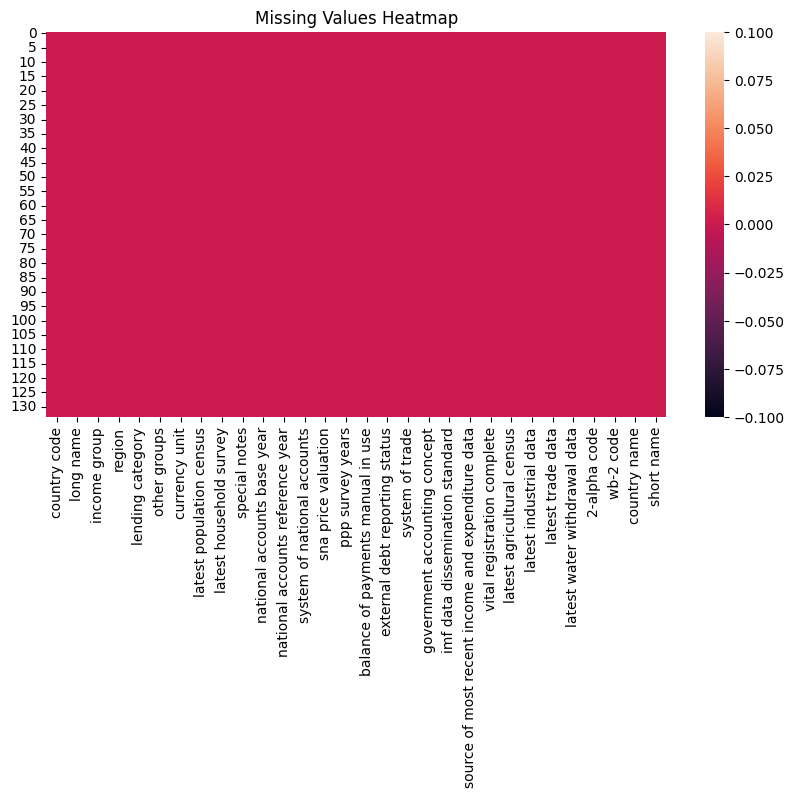

In [53]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull())

plt.title("Missing Values Heatmap")

plt.show()

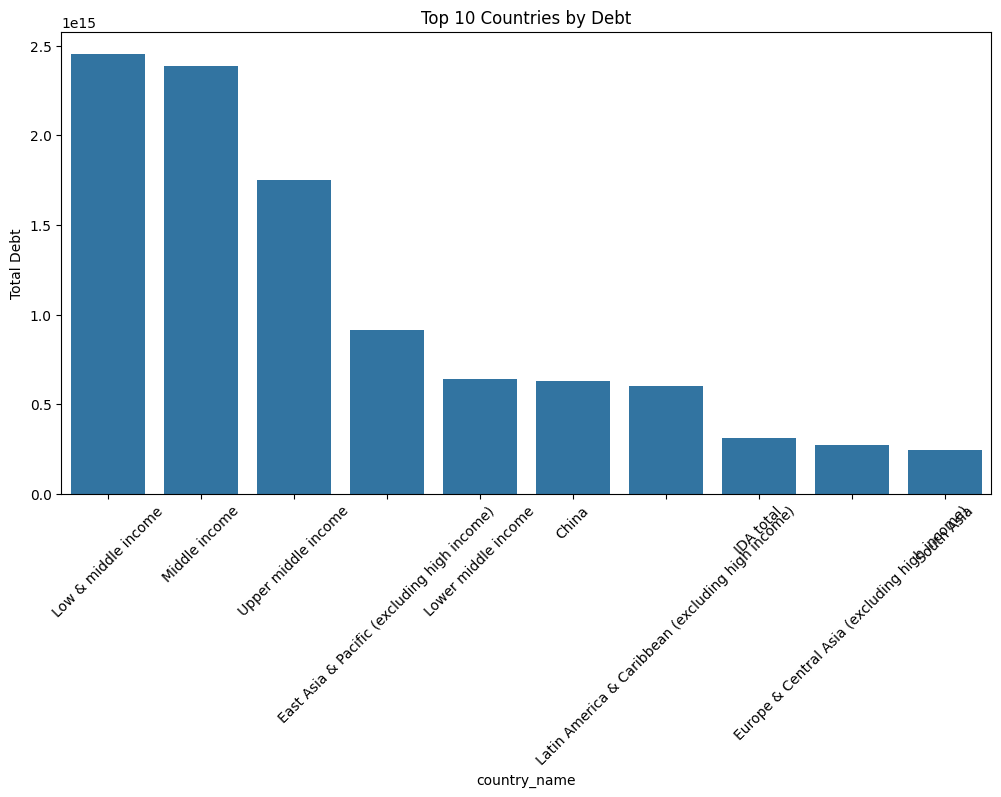

In [54]:
top10 = country_debt.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Debt")

plt.ylabel("Total Debt")

plt.show()

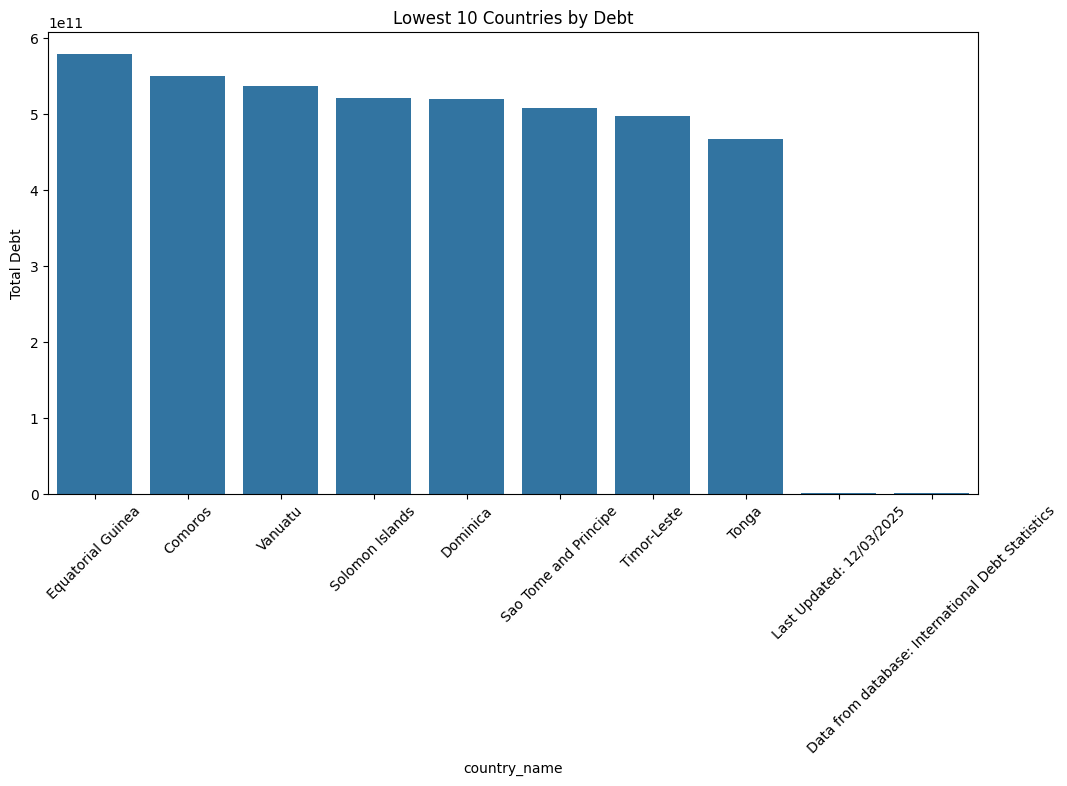

In [55]:
lowest10 = country_debt.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=lowest10.index,
    y=lowest10.values
)

plt.xticks(rotation=45)

plt.title("Lowest 10 Countries by Debt")

plt.ylabel("Total Debt")

plt.show()

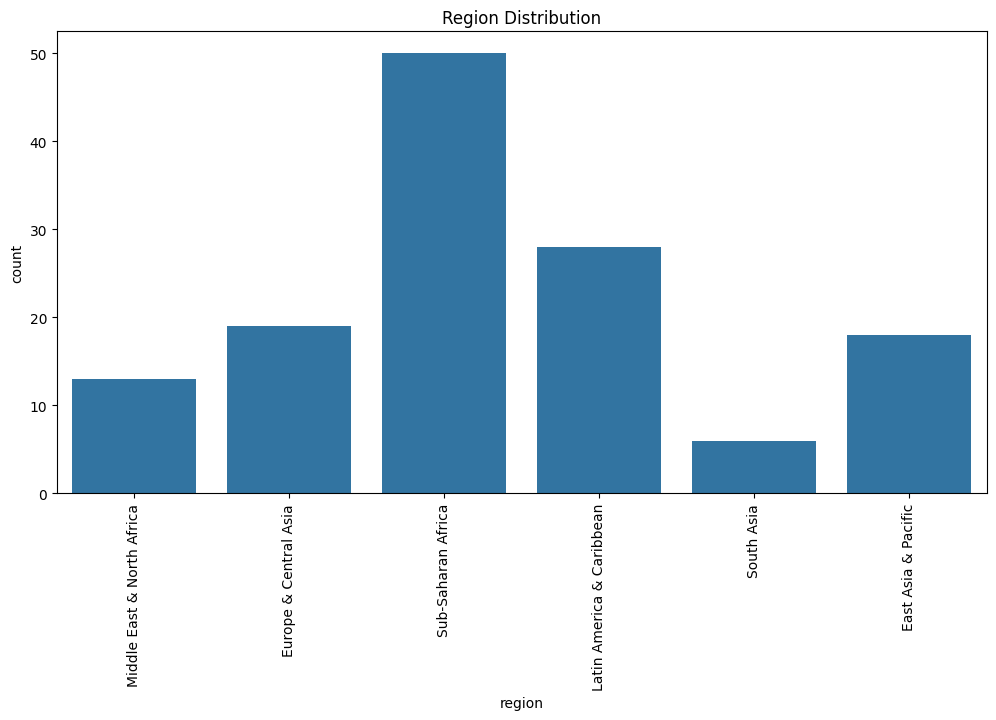

In [56]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='region',
    data=df
)

plt.xticks(rotation=90)

plt.title("Region Distribution")

plt.show()

In [66]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [67]:
df.columns

Index(['country_code', 'long_name', 'income_group', 'region',
       'lending_category', 'other_groups', 'currency_unit',
       'latest_population_census', 'latest_household_survey', 'special_notes',
       'national_accounts_base_year', 'national_accounts_reference_year',
       'system_of_national_accounts', 'sna_price_valuation',
       'ppp_survey_years', 'balance_of_payments_manual_in_use',
       'external_debt_reporting_status', 'system_of_trade',
       'government_accounting_concept', 'imf_data_dissemination_standard',
       'source_of_most_recent_income_and_expenditure_data',
       'vital_registration_complete', 'latest_agricultural_census',
       'latest_industrial_data', 'latest_trade_data',
       'latest_water_withdrawal_data', '2_alpha_code', 'wb_2_code',
       'country_name', 'short_name'],
      dtype='str')

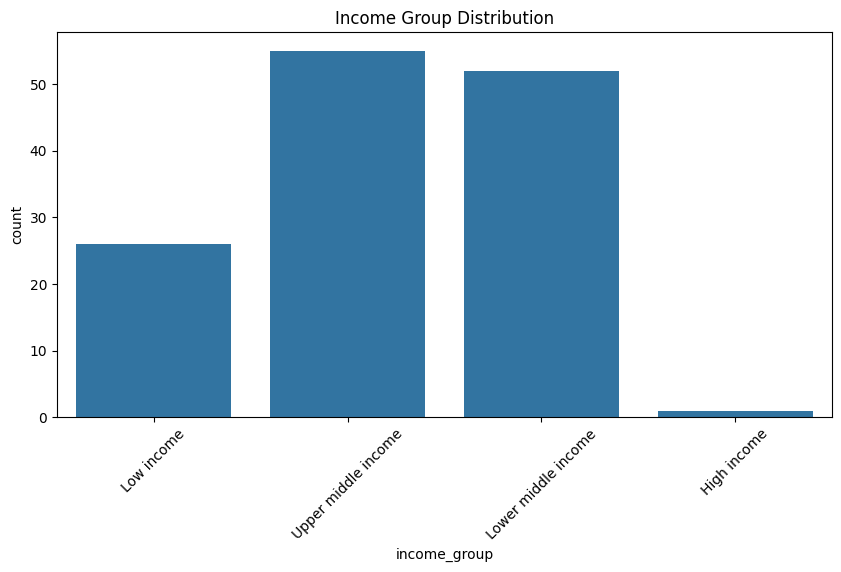

In [68]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='income_group',
    data=df
)

plt.xticks(rotation=45)

plt.title("Income Group Distribution")

plt.show()

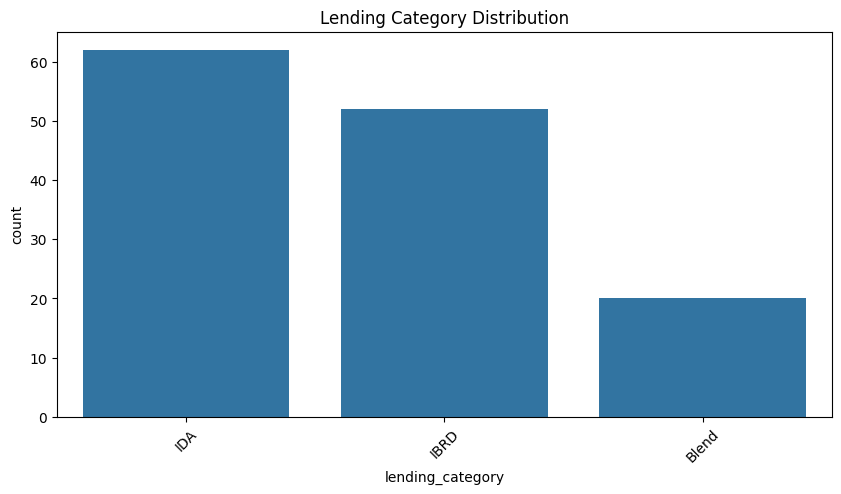

In [69]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='lending_category',
    data=df
)

plt.xticks(rotation=45)

plt.title("Lending Category Distribution")

plt.show()

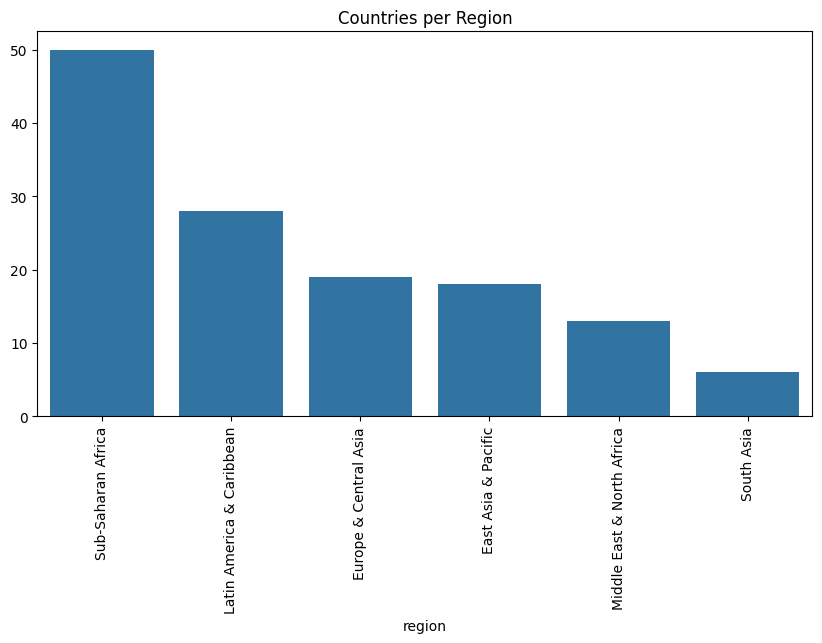

In [70]:
top_regions = df['region'].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_regions.index,
    y=top_regions.values
)

plt.xticks(rotation=90)

plt.title("Countries per Region")

plt.show()

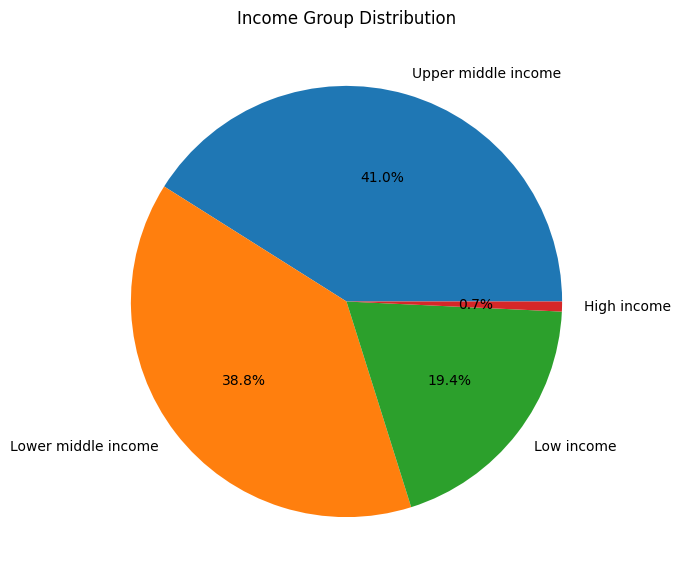

In [71]:
income_counts = df['income_group'].value_counts()

plt.figure(figsize=(7,7))

income_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Income Group Distribution")

plt.show()

In [72]:
df1 = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_Country-Series - Metadata (1).csv")
df2 = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_CountryMetaData.csv")

In [73]:
df1.columns = [col.strip().lower().replace(" ", "_") for col in df1.columns]
df2.columns = [col.strip().lower().replace(" ", "_") for col in df2.columns]

In [74]:
# DISPLAY COLUMN NAMES
# =========================================================
print("DF1 Columns:")
print(df1.columns)

print("\nDF2 Columns:")
print(df2.columns)

DF1 Columns:
Index(['type', 'country_code', 'series_code', 'description', 'country_name',
       'series_name'],
      dtype='str')

DF2 Columns:
Index(['country_code', 'long_name', 'income_group', 'region',
       'lending_category', 'other_groups', 'currency_unit',
       'latest_population_census', 'latest_household_survey', 'special_notes',
       'national_accounts_base_year', 'national_accounts_reference_year',
       'system_of_national_accounts', 'sna_price_valuation',
       'ppp_survey_years', 'balance_of_payments_manual_in_use',
       'external_debt_reporting_status', 'system_of_trade',
       'government_accounting_concept', 'imf_data_dissemination_standard',
       'source_of_most_recent_income_and_expenditure_data',
       'vital_registration_complete', 'latest_agricultural_census',
       'latest_industrial_data', 'latest_trade_data',
       'latest_water_withdrawal_data', '2-alpha_code', 'wb-2_code',
       'country_name', 'short_name'],
      dtype='str')


In [75]:
# MERGE DATASETS
# =========================================================
merged_df = pd.merge(
    df1,
    df2,
    on='country_code',
    how='left',
    suffixes=('_series', '_meta')
)

In [76]:
# SAVE MERGED DATA
# =========================================================
merged_df.to_csv("merged_country_metadata.csv", index=False)

print("\nDatasets merged successfully!")


Datasets merged successfully!


In [77]:
# BASIC EDA

print(merged_df.info())


<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 35 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   type                                               375 non-null    str    
 1   country_code                                       375 non-null    str    
 2   series_code                                        375 non-null    str    
 3   description                                        375 non-null    str    
 4   country_name_series                                375 non-null    str    
 5   series_name                                        375 non-null    str    
 6   long_name                                          375 non-null    str    
 7   income_group                                       375 non-null    str    
 8   region                                             375 non-null    str    
 9   lending_category     

In [78]:
print(merged_df.head())

             type country_code        series_code  \
0  Country-Series          AFG  BX.KLT.DINV.CD.DT   
1  Country-Series          AFG        SP.POP.TOTL   
2  Country-Series          AFG     DT.DOD.DECT.CD   
3  Country-Series          AGO     DT.DOD.DECT.CD   
4  Country-Series          AGO        SP.POP.TOTL   

                                         description country_name_series  \
0  Data on Foreign Direct Investment are based on...         Afghanistan   
1  Data source: United Nations World Population P...         Afghanistan   
2  Long-term public and publicly guaranteed, long...         Afghanistan   
3  Long-term public and publicly guaranteed debt ...              Angola   
4  Data source: United Nations World Population P...              Angola   

                                         series_name  \
0  Foreign direct investment, net inflows in repo...   
1                                  Population, total   
2     External debt stocks, total (DOD, current US$)   


In [79]:
print("Rows:", merged_df.shape[0])
print("Columns:", merged_df.shape[1])

Rows: 375
Columns: 35


In [80]:
print(merged_df.isnull().sum())

type                                                 0
country_code                                         0
series_code                                          0
description                                          0
country_name_series                                  0
series_name                                          0
long_name                                            0
income_group                                         0
region                                               0
lending_category                                     0
other_groups                                         0
currency_unit                                        0
latest_population_census                             0
latest_household_survey                              0
special_notes                                        0
national_accounts_base_year                          0
national_accounts_reference_year                     0
system_of_national_accounts                          0
sna_price_

In [81]:
print("Duplicate Rows:", merged_df.duplicated().sum())

Duplicate Rows: 0


In [82]:
print(merged_df.describe(include='all'))

                  type country_code        series_code  \
count              375          375                375   
unique               1          131                  7   
top     Country-Series          IND  BX.KLT.DINV.CD.DT   
freq               375            6                127   
mean               NaN          NaN                NaN   
std                NaN          NaN                NaN   
min                NaN          NaN                NaN   
25%                NaN          NaN                NaN   
50%                NaN          NaN                NaN   
75%                NaN          NaN                NaN   
max                NaN          NaN                NaN   

                                              description country_name_series  \
count                                                 375                 375   
unique                                                130                 131   
top     Data on Foreign Direct Investment are based on...   

In [83]:
if 'country_name_series' in merged_df.columns:
    print("\nUnique Countries:",
          merged_df['country_name_series'].nunique())

if 'series_code' in merged_df.columns:
    print("Unique Series Codes:",
          merged_df['series_code'].nunique())


Unique Countries: 131
Unique Series Codes: 7


In [84]:
# VALUE COUNTS
# =========================================================
if 'region' in merged_df.columns:
    print("\n================ REGION COUNTS ================\n")
    print(merged_df['region'].value_counts())


================ REGION COUNTS ================

region
Sub-Saharan Africa            139
Latin America & Caribbean      71
Europe & Central Asia          56
East Asia & Pacific            50
Middle East & North Africa     38
South Asia                     21
Name: count, dtype: int64


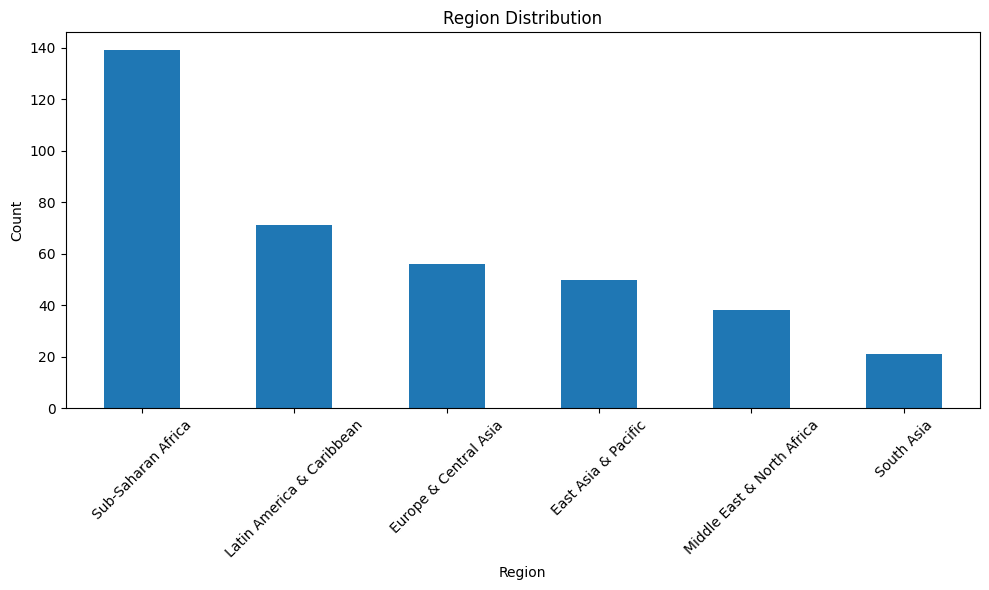

In [85]:
# PLOT - REGION DISTRIBUTION
# =========================================================
if 'region' in merged_df.columns:

    region_counts = merged_df['region'].value_counts()

    plt.figure(figsize=(10, 6))
    region_counts.plot(kind='bar')

    plt.title("Region Distribution")
    plt.xlabel("Region")
    plt.ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig("region_distribution.png")
    plt.show()

In [86]:
# CORRELATION MATRIX (NUMERIC COLUMNS)
# =========================================================
numeric_df = merged_df.select_dtypes(include=['int64', 'float64'])

if not numeric_df.empty:

    correlation = numeric_df.corr()

    print("\n================ CORRELATION MATRIX ================\n")
    print(correlation)



================ CORRELATION MATRIX ================

                                  national_accounts_reference_year  \
national_accounts_reference_year                          1.000000   
latest_industrial_data                                   -0.133672   
latest_trade_data                                         0.025726   
latest_water_withdrawal_data                              0.004766   

                                  latest_industrial_data  latest_trade_data  \
national_accounts_reference_year               -0.133672           0.025726   
latest_industrial_data                          1.000000           0.111727   
latest_trade_data                               0.111727           1.000000   
latest_water_withdrawal_data                    0.279221           0.122468   

                                  latest_water_withdrawal_data  
national_accounts_reference_year                      0.004766  
latest_industrial_data                                0.279221  
lat

In [87]:
# EXPORT CLEANED DATA
# =========================================================
merged_df.to_csv("final_merged_dataset.csv", index=False)

print("\nEDA Completed Successfully!")


EDA Completed Successfully!


In [88]:
df1 = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_Country-Series - Metadata (1).csv")
df2 = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_CountryMetaData.csv")


In [89]:
print(df1.head())


             type country_code        series_code  \
0  Country-Series          AFG  BX.KLT.DINV.CD.DT   
1  Country-Series          AFG        SP.POP.TOTL   
2  Country-Series          AFG     DT.DOD.DECT.CD   
3  Country-Series          AGO     DT.DOD.DECT.CD   
4  Country-Series          AGO        SP.POP.TOTL   

                                         description country_name  \
0  Data on Foreign Direct Investment are based on...  Afghanistan   
1  Data source: United Nations World Population P...  Afghanistan   
2  Long-term public and publicly guaranteed, long...  Afghanistan   
3  Long-term public and publicly guaranteed debt ...       Angola   
4  Data source: United Nations World Population P...       Angola   

                                         series_name  
0  Foreign direct investment, net inflows in repo...  
1                                  Population, total  
2     External debt stocks, total (DOD, current US$)  
3     External debt stocks, total (DOD, curren

In [90]:
print(df2.head())

  country code                                long name         income group  \
0          AFG             Islamic State of Afghanistan           Low income   
1          ALB                      Republic of Albania  Upper middle income   
2          DZA  People's Democratic Republic of Algeria  Upper middle income   
3          AGO              People's Republic of Angola  Lower middle income   
4          ARG                       Argentine Republic  Upper middle income   

                       region lending category other groups   currency unit  \
0  Middle East & North Africa              IDA         HIPC  Afghan afghani   
1       Europe & Central Asia             IBRD         HIPC    Albanian lek   
2  Middle East & North Africa             IBRD         HIPC  Algerian dinar   
3          Sub-Saharan Africa             IBRD         HIPC  Angolan kwanza   
4   Latin America & Caribbean             IBRD         HIPC  Argentine peso   

  latest population census                  

In [91]:
print("\nShape:", df1.shape)


Shape: (375, 6)


In [92]:
print("\nShape:", df2.shape)


Shape: (134, 30)


In [93]:
print(df1.columns)


Index(['type', 'country_code', 'series_code', 'description', 'country_name',
       'series_name'],
      dtype='str')


In [94]:
print(df2.columns)


Index(['country code', 'long name', 'income group', 'region',
       'lending category', 'other groups', 'currency unit',
       'latest population census', 'latest household survey', 'special notes',
       'national accounts base year', 'national accounts reference year',
       'system of national accounts', 'sna price valuation',
       'ppp survey years', 'balance of payments manual in use',
       'external debt reporting status', 'system of trade',
       'government accounting concept', 'imf data dissemination standard',
       'source of most recent income and expenditure data',
       'vital registration complete', 'latest agricultural census',
       'latest industrial data', 'latest trade data',
       'latest water withdrawal data', '2-alpha code', 'wb-2 code',
       'country name', 'short name'],
      dtype='str')


In [95]:
print(df1.info())

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          375 non-null    str  
 1   country_code  375 non-null    str  
 2   series_code   375 non-null    str  
 3   description   375 non-null    str  
 4   country_name  375 non-null    str  
 5   series_name   375 non-null    str  
dtypes: str(6)
memory usage: 17.7 KB
None


In [96]:
print(df2.info())

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 30 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   country code                                       134 non-null    str    
 1   long name                                          134 non-null    str    
 2   income group                                       134 non-null    str    
 3   region                                             134 non-null    str    
 4   lending category                                   134 non-null    str    
 5   other groups                                       134 non-null    str    
 6   currency unit                                      134 non-null    str    
 7   latest population census                           134 non-null    str    
 8   latest household survey                            134 non-null    str    
 9   special notes        

In [97]:
print(df1.isnull().sum())

type            0
country_code    0
series_code     0
description     0
country_name    0
series_name     0
dtype: int64


In [98]:
print(df2.isnull().sum())

country code                                         0
long name                                            0
income group                                         0
region                                               0
lending category                                     0
other groups                                         0
currency unit                                        0
latest population census                             0
latest household survey                              0
special notes                                        0
national accounts base year                          0
national accounts reference year                     0
system of national accounts                          0
sna price valuation                                  0
ppp survey years                                     0
balance of payments manual in use                    0
external debt reporting status                       0
system of trade                                      0
government

<Figure size 1000x500 with 0 Axes>

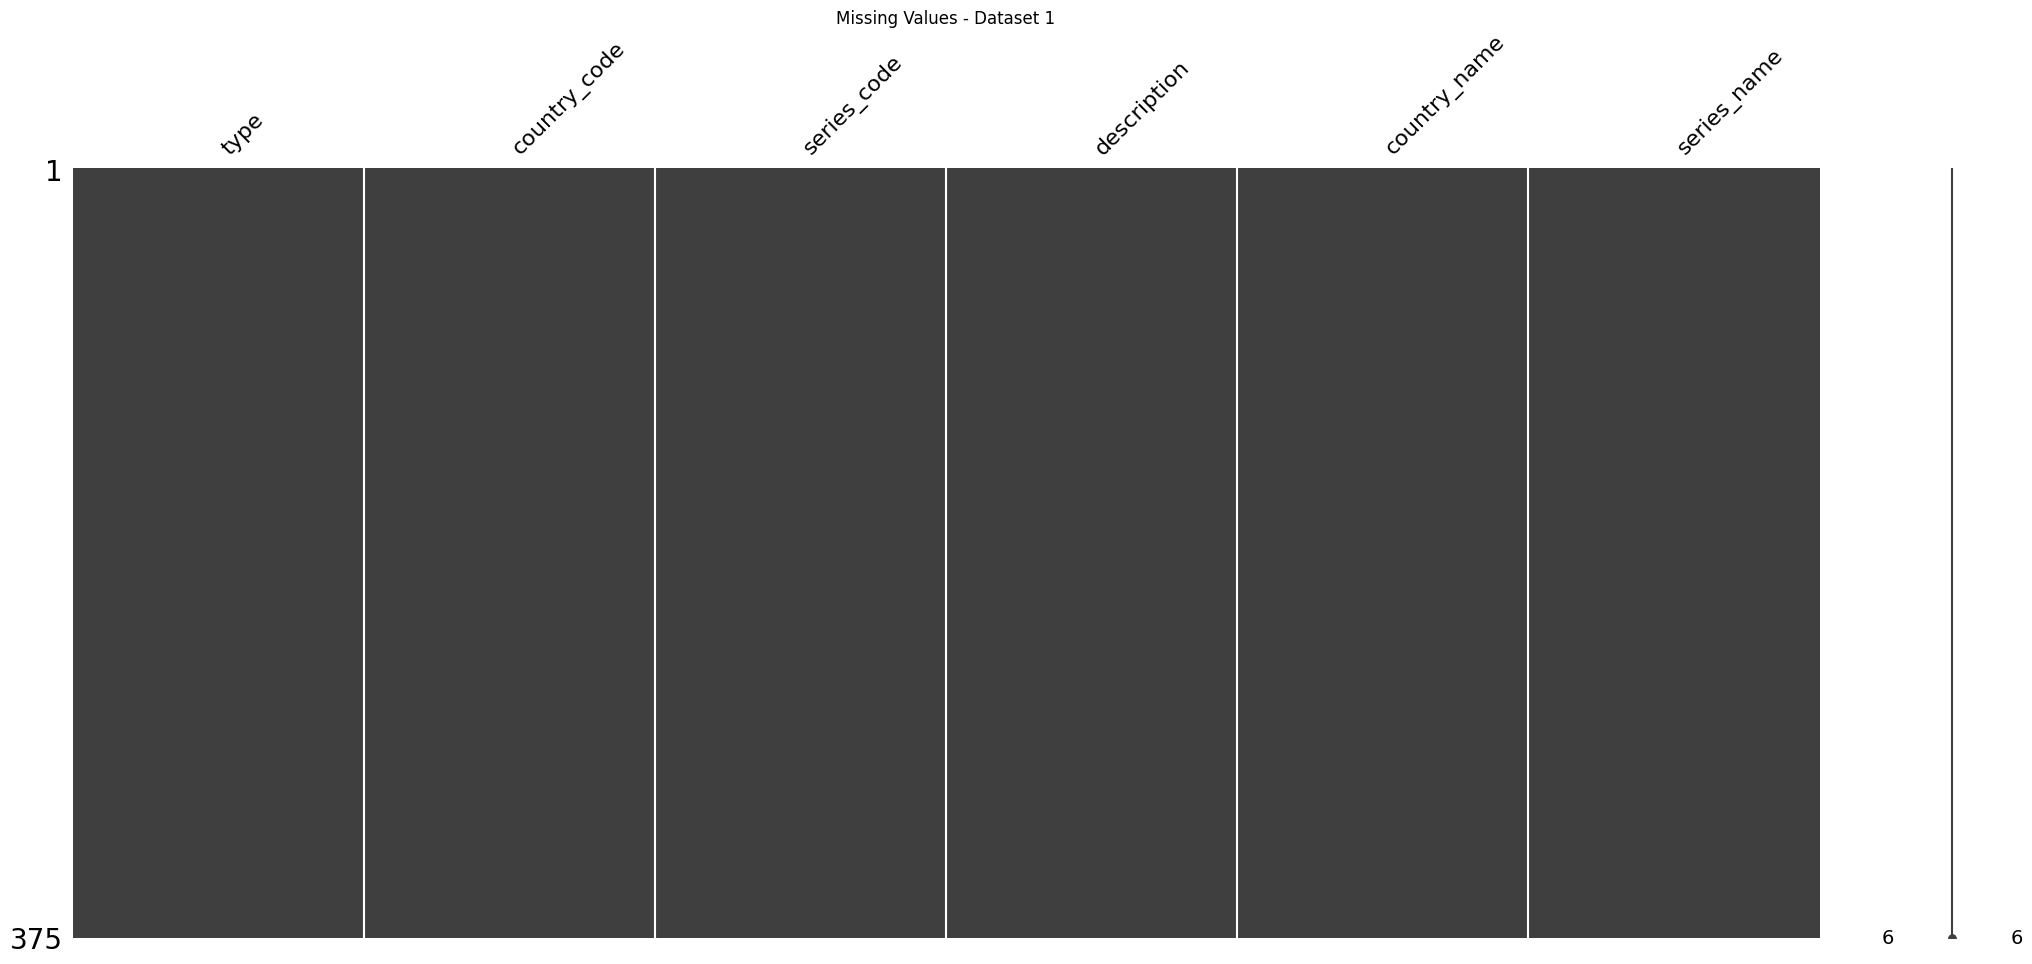

In [99]:
plt.figure(figsize=(10,5))
msno.matrix(df1)
plt.title("Missing Values - Dataset 1")
plt.show()

<Figure size 1000x500 with 0 Axes>

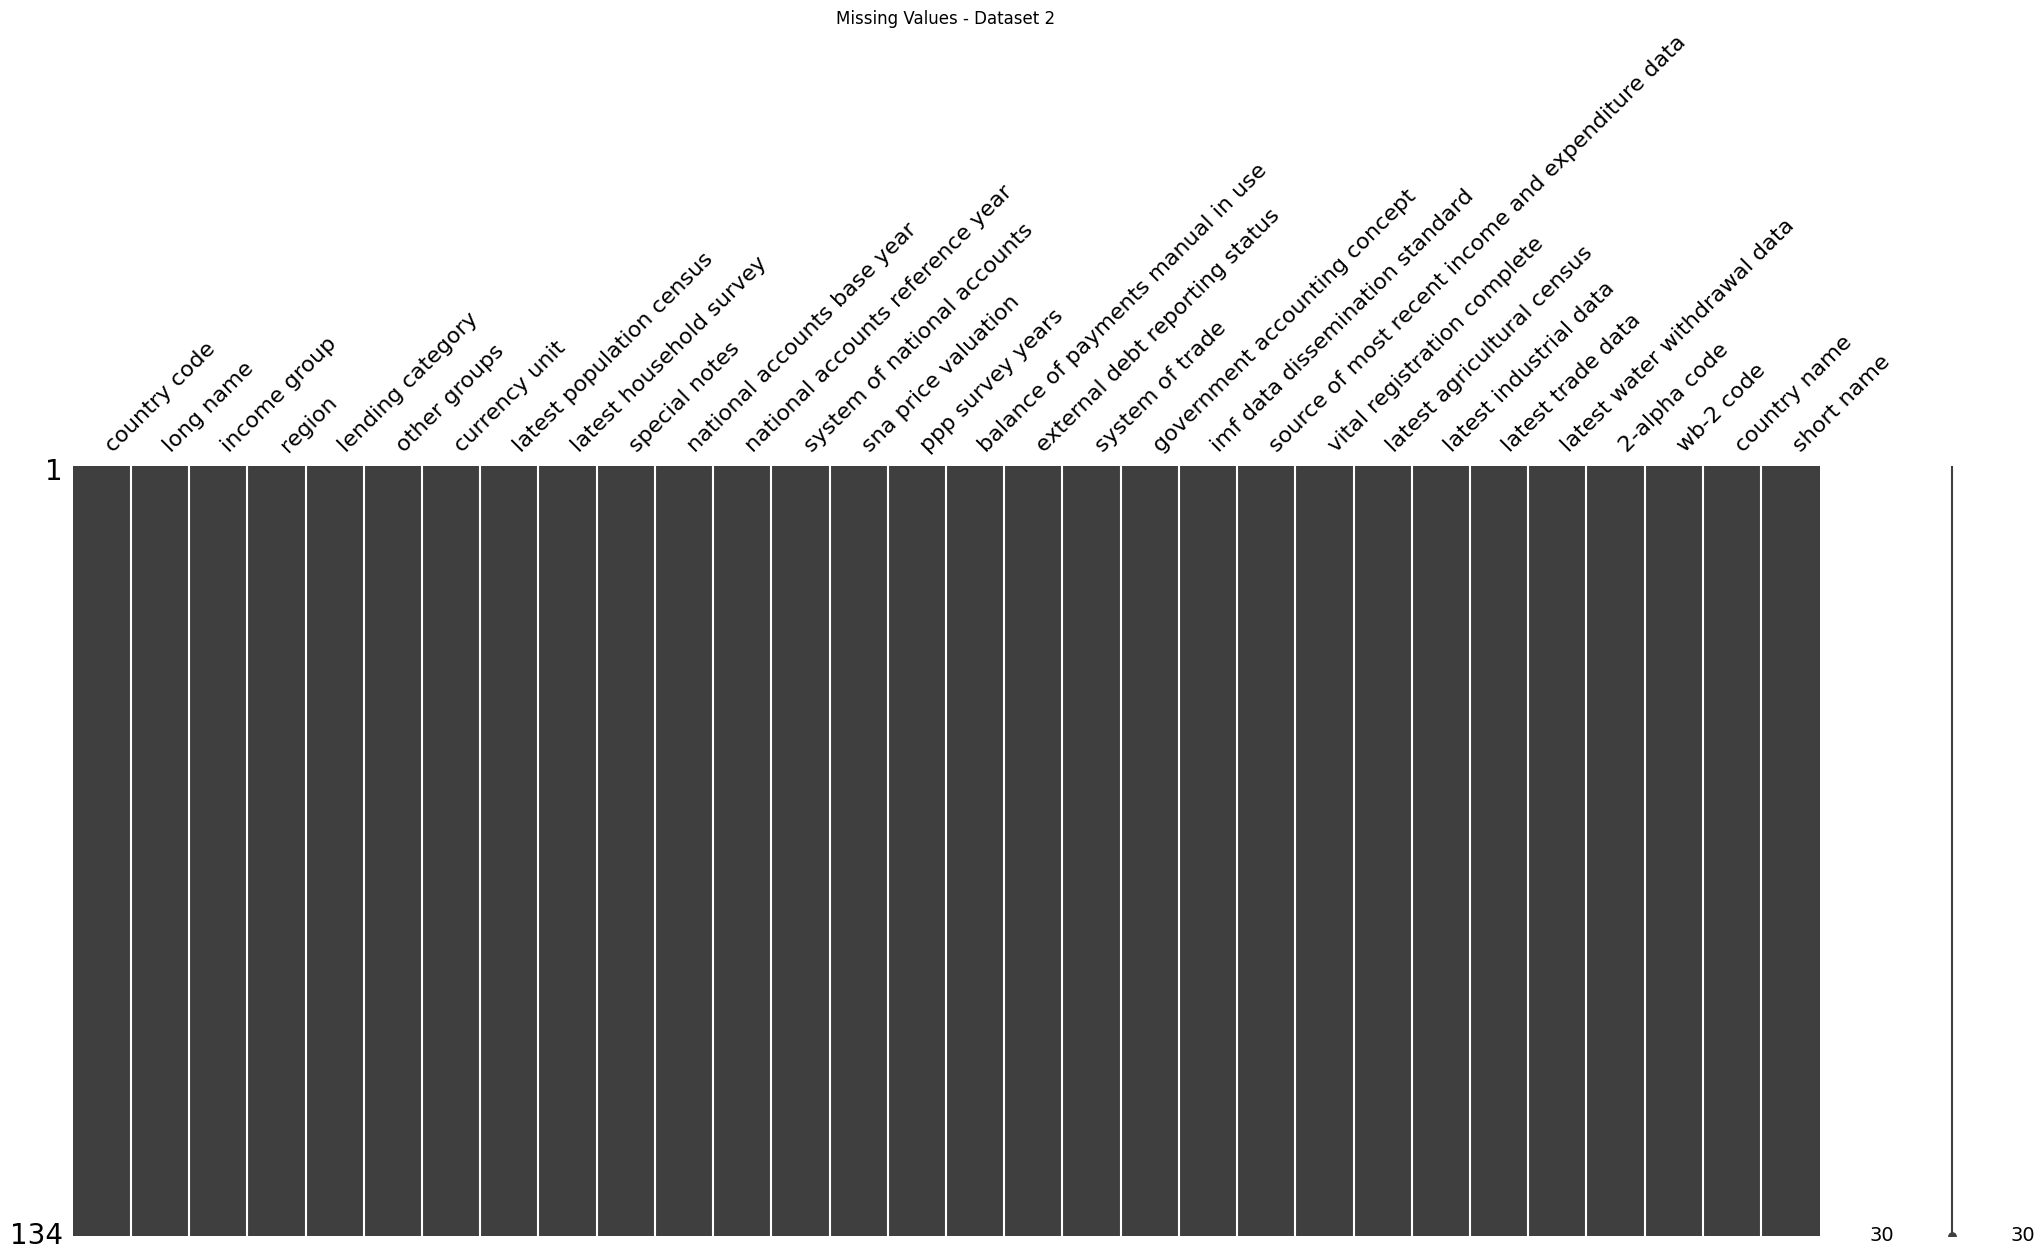

In [100]:
plt.figure(figsize=(10,5))
msno.matrix(df2)
plt.title("Missing Values - Dataset 2")
plt.show()

        EDA DATASET-4   

In [101]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_FootNoteMetaData.csv")

In [102]:
df.head()

,type,country code,series code,time code,description,country name,series name
0,FootNote,AFG,BX.TRF.PWKR.CD.DT,2024 (YR2024),Data on Personal Transfers and Compensation of...,Afghanistan,Personal transfers and compensation of employe...
1,FootNote,AFG,BX.TRF.PWKR.CD.DT,2023 (YR2023),Source: United Nations Conference on Trade and...,Afghanistan,Personal transfers and compensation of employe...
2,FootNote,AFG,BX.TRF.PWKR.CD.DT,2021 (YR2021),Source: United Nations Conference on Trade and...,Afghanistan,Personal transfers and compensation of employe...
3,FootNote,AFG,BX.TRF.PWKR.CD.DT,2022 (YR2022),Source: United Nations Conference on Trade and...,Afghanistan,Personal transfers and compensation of employe...
4,FootNote,AFG,BX.KLT.DINV.CD.DT,2021 (YR2021),Source: United Nations Conference on Trade and...,Afghanistan,"Foreign direct investment, net inflows in repo..."


In [103]:
print(df.shape)

(2673, 7)


In [104]:


# Change column names
df.columns = df.columns.str.lower().str.replace(' ', '_')



In [105]:
print(df.columns)

Index(['type', 'country_code', 'series_code', 'time_code', 'description',
       'country_name', 'series_name'],
      dtype='str')


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          2673 non-null   str  
 1   country_code  2673 non-null   str  
 2   series_code   2673 non-null   str  
 3   time_code     2673 non-null   str  
 4   description   2673 non-null   str  
 5   country_name  2673 non-null   str  
 6   series_name   2673 non-null   str  
dtypes: str(7)
memory usage: 146.3 KB


In [107]:
df.describe()

,type,country_code,series_code,time_code,description,country_name,series_name
count,2673,2673,2673,2673,2673,2673,2673
unique,1,106,26,55,64,106,26
top,FootNote,IRN,BX.KLT.DINV.CD.DT,2024 (YR2024),Source: United Nations Conference on Trade and...,"Iran, Islamic Rep.","Foreign direct investment, net inflows in repo..."
freq,2673,143,1206,208,1166,143,1206


In [108]:
df.isnull().sum()

type            0
country_code    0
series_code     0
time_code       0
description     0
country_name    0
series_name     0
dtype: int64

<Figure size 1000x500 with 0 Axes>

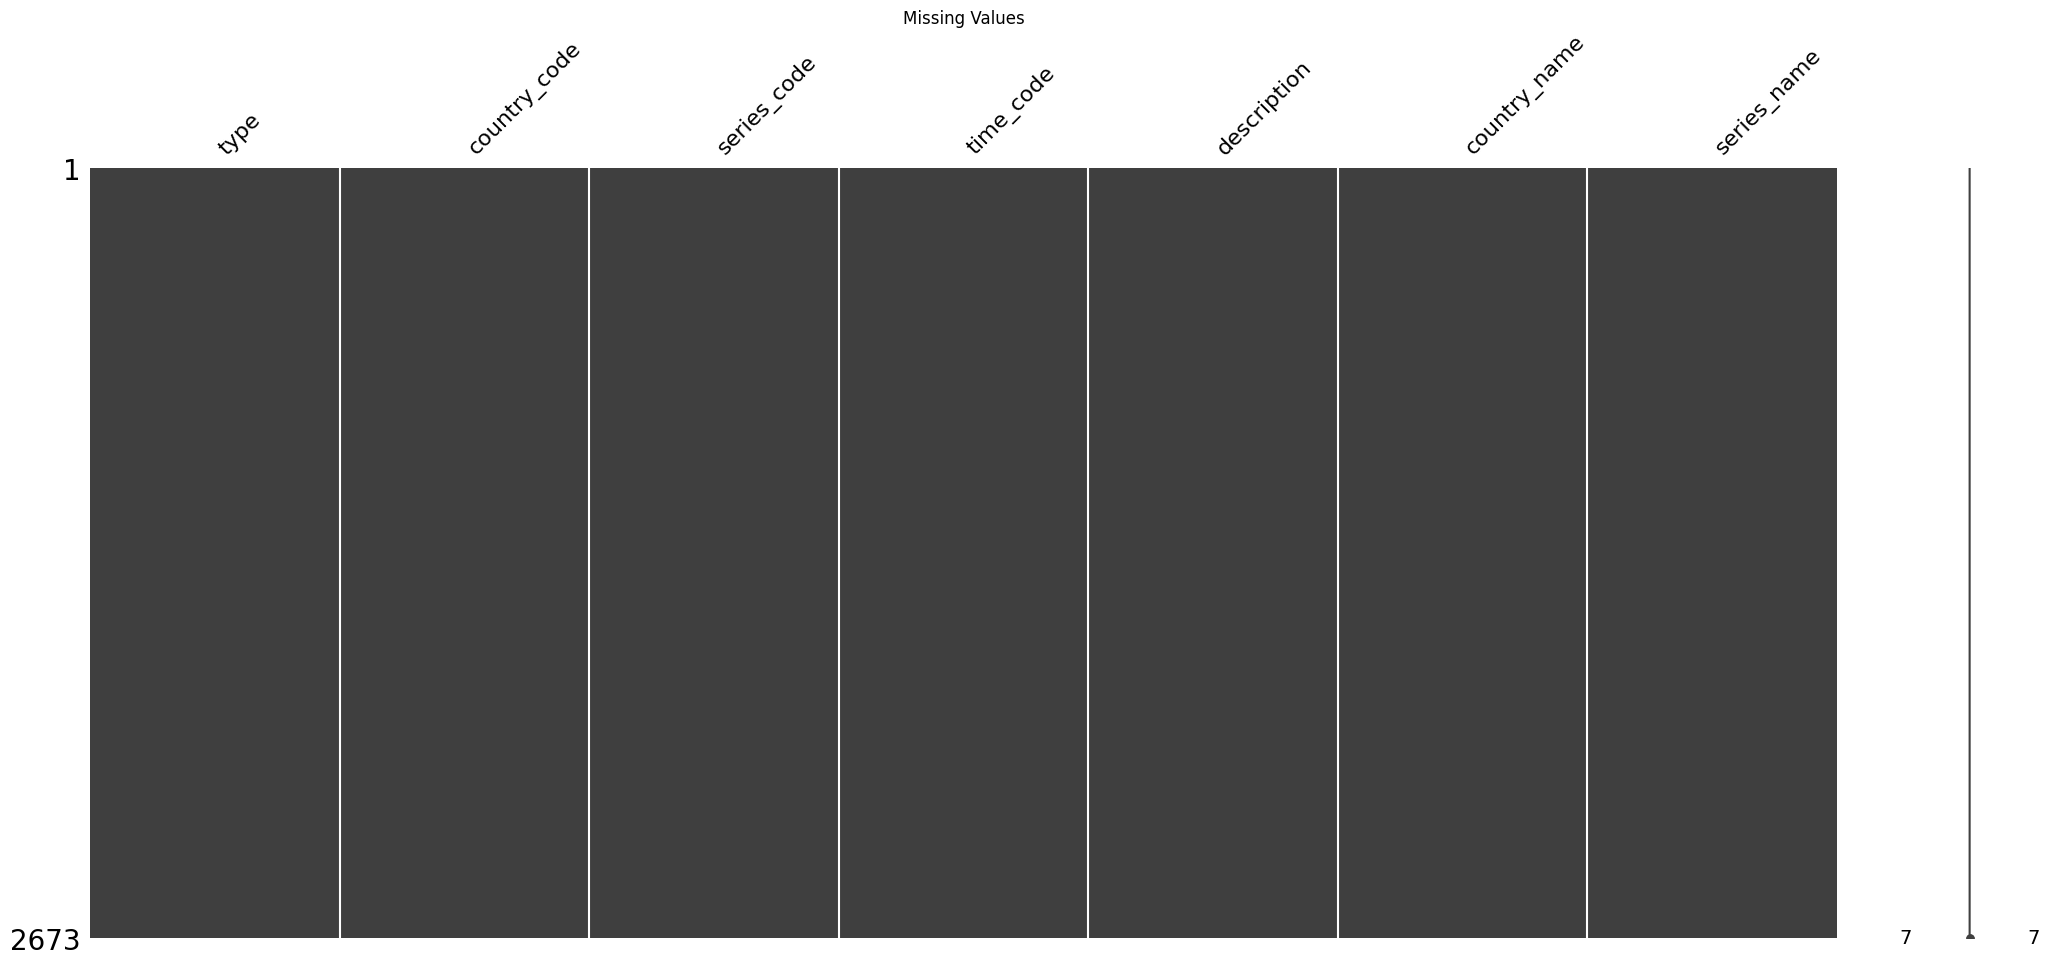

In [109]:
# MISSING VALUE VISUALIZATION
# =========================================================

plt.figure(figsize=(10,5))

msno.matrix(df)

plt.title("Missing Values")

plt.show()

In [110]:
# NUMERIC COLUMNS
# =========================================================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("\nNumeric Columns:")
print(numeric_df.columns)



Numeric Columns:
Index([], dtype='str')


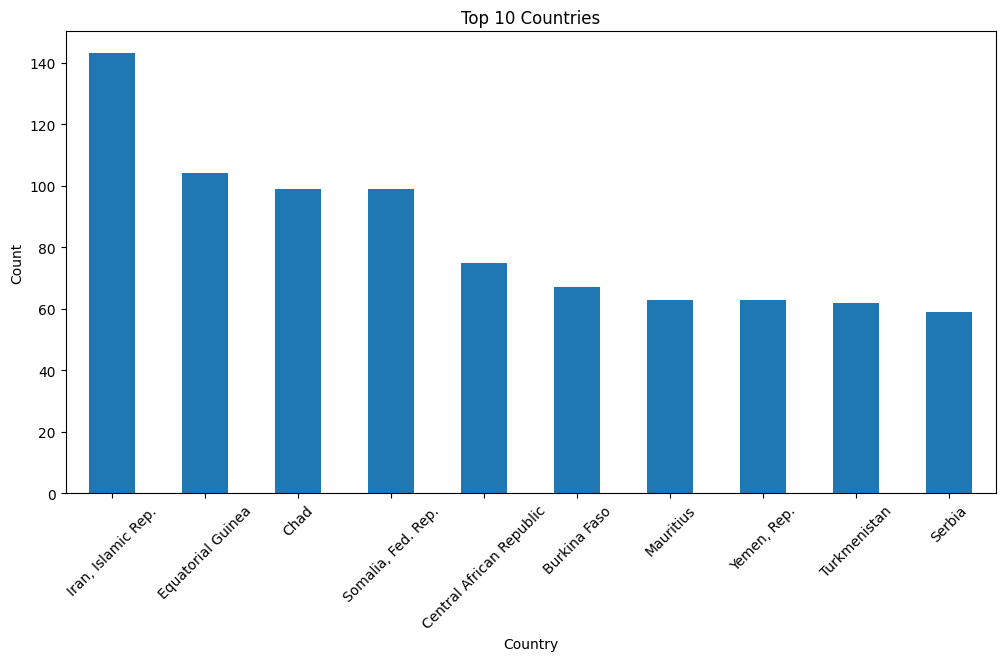

In [111]:
# COUNTRY COUNT
# =========================================================

plt.figure(figsize=(12,6))

df['country_name'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


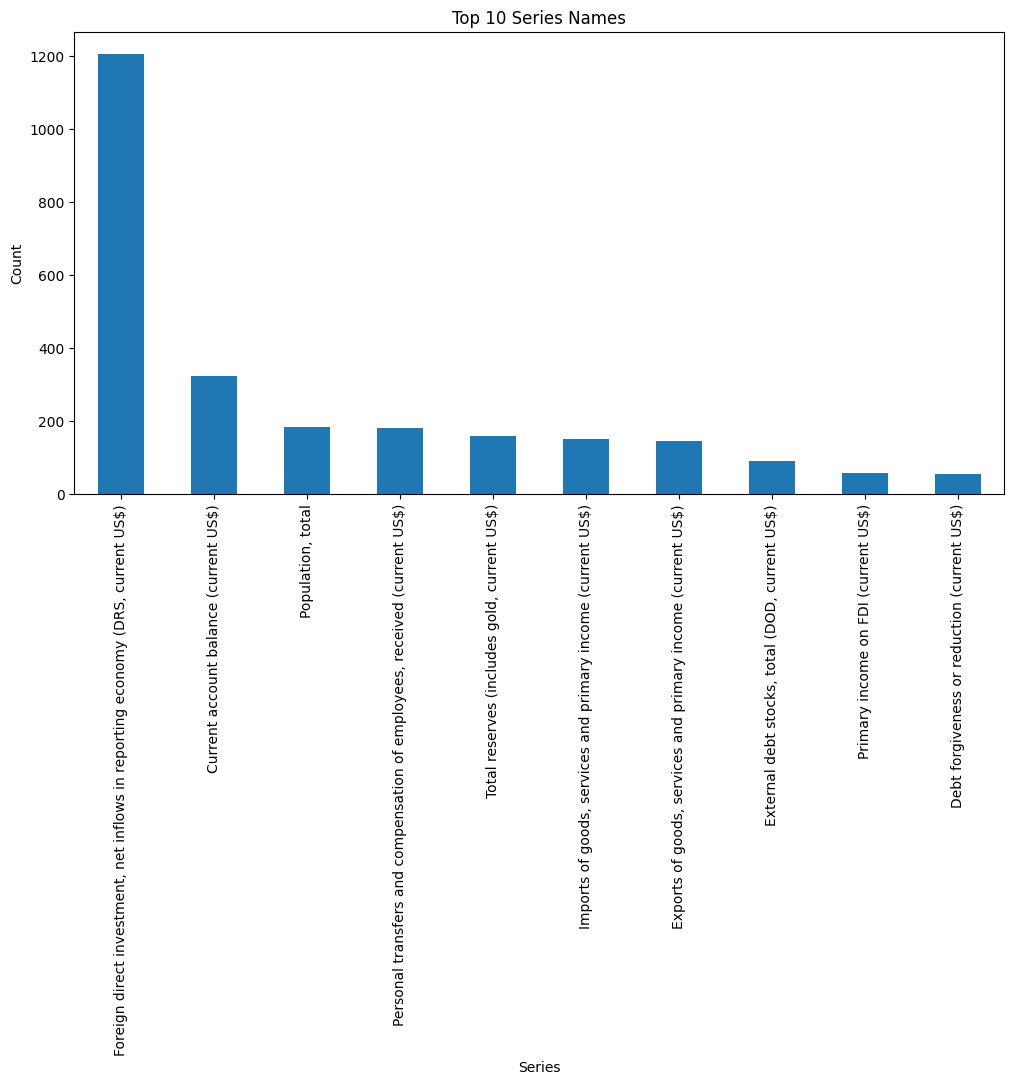

In [112]:
# SERIES COUNT
# =========================================================

plt.figure(figsize=(12,6))

df['series_name'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Series Names")

plt.xlabel("Series")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

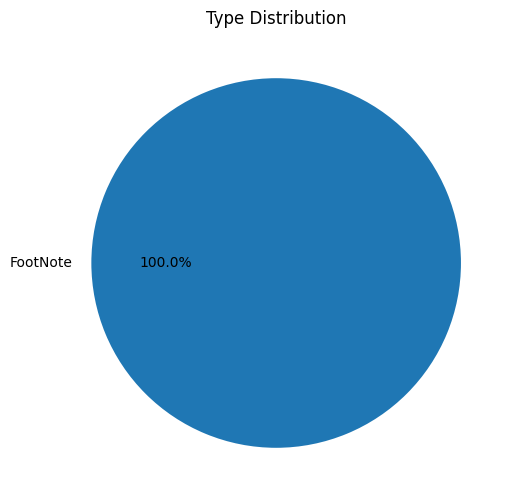

In [113]:
# TYPE DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,6))

df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Type Distribution")

plt.ylabel("")

plt.show()

In [114]:
# CATEGORICAL COLUMNS
# =========================================================

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    print(f"\nTop Values in {col}")

    print(df[col].value_counts().head(10))

print("\nEDA COMPLETED SUCCESSFULLY")


Top Values in type
type
FootNote    2673
Name: count, dtype: int64

Top Values in country_code
country_code
IRN    143
GNQ    104
TCD     99
SOM     99
CAF     75
BFA     67
MUS     63
YEM     63
TKM     62
SRB     59
Name: count, dtype: int64

Top Values in series_code
series_code
BX.KLT.DINV.CD.DT    1206
BN.CAB.XOKA.CD        324
SP.POP.TOTL           184
BX.TRF.PWKR.CD.DT     181
FI.RES.TOTL.CD        159
BM.GSR.TOTL.CD        151
BX.GSR.TOTL.CD        145
DT.DOD.DECT.CD         92
BX.KLT.DREM.CD.DT      57
DT.DFR.DPPG.CD         56
Name: count, dtype: int64

Top Values in time_code
time_code
2024 (YR2024)    208
2009 (YR2009)    138
2023 (YR2023)     93
2006 (YR2006)     88
2007 (YR2007)     82
2001 (YR2001)     82
2002 (YR2002)     80
2000 (YR2000)     77
2003 (YR2003)     74
2004 (YR2004)     69
Name: count, dtype: int64

Top Values in description
description
Source: United Nations Conference on Trade and Development, Foreign Direct Investment Online database.                  

C:\Users\Dell\AppData\Local\Temp\ipykernel_11684\774930126.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


EDA DATA SET -5

In [115]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_SeriesMetaData.csv")

In [116]:
df.head()

,series code,indicator name,short definition,long definition,source,topic,dataset,periodicity,aggregation method
0,DT.GPA.DPPG,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Grace period is the period from the date of si...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average
1,DT.GPA.OFFT,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Grace period is the period from the date of si...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average
2,DT.GPA.PRVT,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Grace period is the period from the date of si...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average
3,DT.GRE.DPPG,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,The grant element of a loan is the grant equiv...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average
4,DT.GRE.OFFT,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,The grant element of a loan is the grant equiv...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   series code         572 non-null    str  
 1   indicator name      572 non-null    str  
 2   short definition    572 non-null    str  
 3   long definition     572 non-null    str  
 4   source              572 non-null    str  
 5   topic               572 non-null    str  
 6   dataset             572 non-null    str  
 7   periodicity         572 non-null    str  
 8   aggregation method  572 non-null    str  
dtypes: str(9)
memory usage: 40.3 KB


In [118]:
df.shape

(572, 9)

In [119]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [120]:
df.columns

Index(['series_code', 'indicator_name', 'short_definition', 'long_definition',
       'source', 'topic', 'dataset', 'periodicity', 'aggregation_method'],
      dtype='str')

In [121]:
print(df.isnull().sum())

series_code           0
indicator_name        0
short_definition      0
long_definition       0
source                0
topic                 0
dataset               0
periodicity           0
aggregation_method    0
dtype: int64


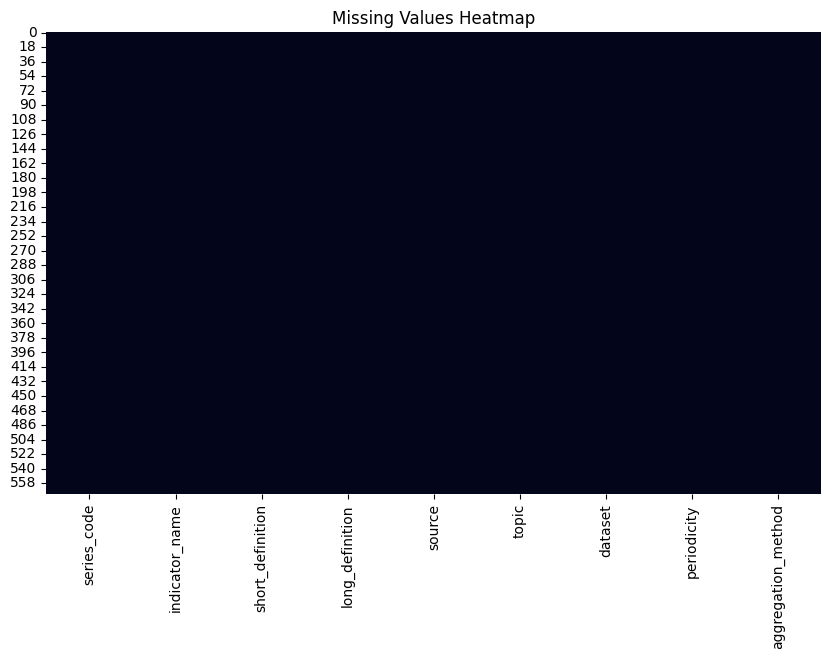

In [122]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [123]:
print(df.describe())

        series_code                                     indicator_name  \
count           572                                                572   
unique          572                                                572   
top     DT.GPA.DPPG  Average grace period on new external debt comm...   
freq              1                                                  1   

                                         short_definition  \
count                                                 572   
unique                                                558   
top     Total external debt is debt owed to nonresiden...   
freq                                                    2   

                                          long_definition  \
count                                                 572   
unique                                                558   
top     Total external debt is debt owed to nonresiden...   
freq                                                    2   

                 

In [124]:
print(df['topic'].value_counts())

topic
Economic Policy & Debt: External debt: Debt outstanding                                   77
Economic Policy & Debt: External debt: Net flows                                          75
Economic Policy & Debt: External debt: Interest                                           71
Economic Policy & Debt: External debt: Amortization                                       68
Economic Policy & Debt: External debt: Disbursements                                      68
Economic Policy & Debt: External debt: Debt service                                       68
Economic Policy & Debt: External debt: Net transfers                                      67
Economic Policy & Debt: External debt: Arrears, reschedulings, etc.                       22
Economic Policy & Debt: External debt: Terms                                              12
Economic Policy & Debt: External debt: Debt ratios & other items                          10
Economic Policy & Debt: External debt: Currency composition     

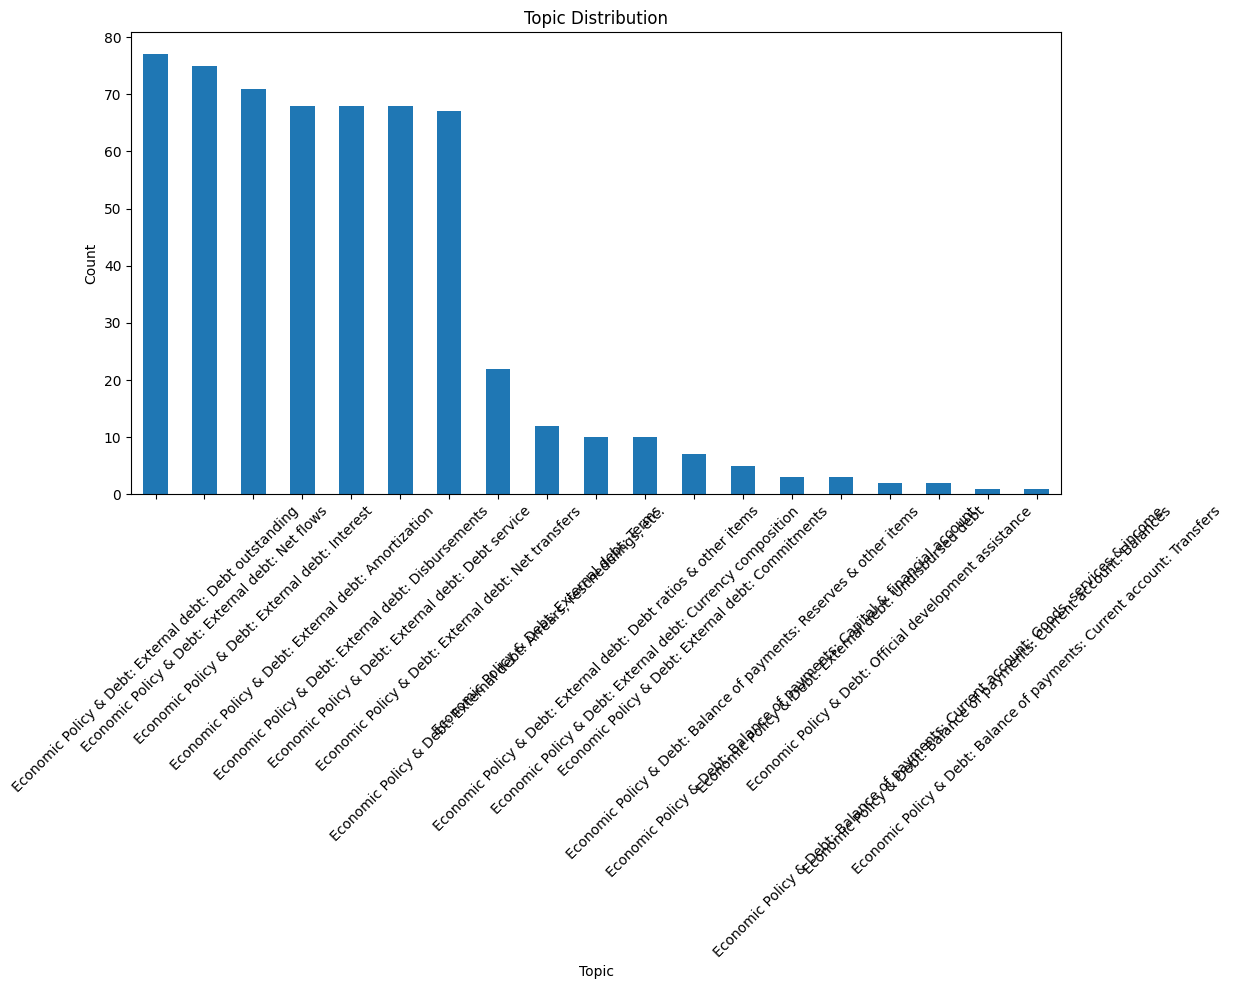

In [125]:
plt.figure(figsize=(12,6))

df['topic'].value_counts().plot(kind='bar')

plt.title("Topic Distribution")

plt.xlabel("Topic")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [126]:
print(df['aggregation_method'].value_counts())

aggregation_method
Sum                 537
Weighted average     33
Gap-filled total      2
Name: count, dtype: int64


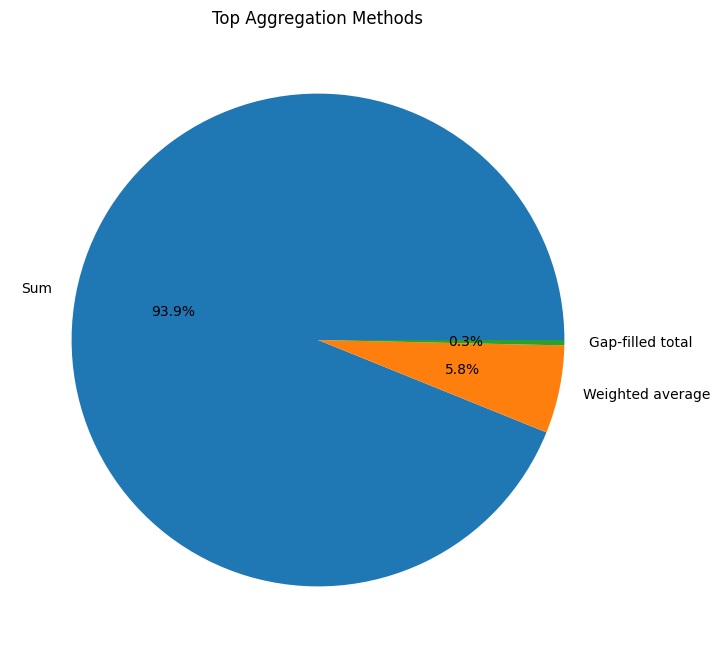

In [127]:
plt.figure(figsize=(8,8))

df['aggregation_method'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top Aggregation Methods")

plt.ylabel("")

plt.show()

In [128]:
print(df['dataset'].value_counts())

dataset
International Debt Statistics    572
Name: count, dtype: int64


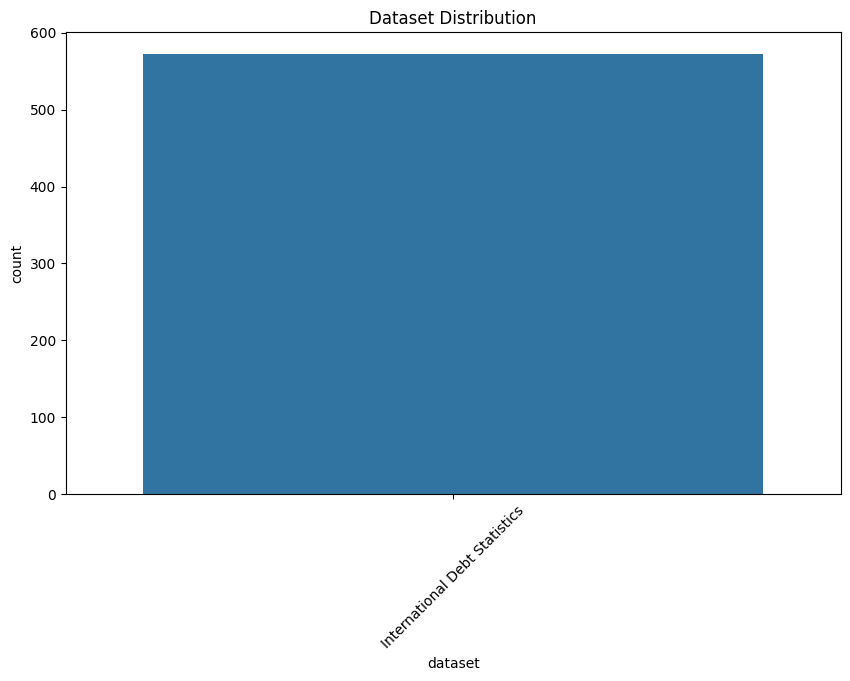

In [129]:
plt.figure(figsize=(10,6))

sns.countplot(x='dataset', data=df)

plt.xticks(rotation=45)

plt.title("Dataset Distribution")

plt.show()

In [130]:
print(df.describe(include='all'))

        series_code                                     indicator_name  \
count           572                                                572   
unique          572                                                572   
top     DT.GPA.DPPG  Average grace period on new external debt comm...   
freq              1                                                  1   

                                         short_definition  \
count                                                 572   
unique                                                558   
top     Total external debt is debt owed to nonresiden...   
freq                                                    2   

                                          long_definition  \
count                                                 572   
unique                                                558   
top     Total external debt is debt owed to nonresiden...   
freq                                                    2   

                 

merging 2 3

In [131]:
df3 = pd.read_csv(
    r"C:\Users\Dell\Downloads\cleaned_IDS_ALLCountries_Data (1).csv"
)

In [132]:
meta= pd.read_csv(r"C:\Users\Dell\Downloads\cleaned_IDS_CountryMetaData.csv")

In [133]:
merged_df = pd.merge(
    df3,
    meta[['country code', 'region']],
    left_on='country_code',
    right_on='country code',
    how='left'
)

In [134]:
print(merged_df.head())

  country_name country_code counterpart-area_name counterpart-area_code  \
0  Afghanistan   AFG                        World                   WLD   
1  Afghanistan   AFG                        World                   WLD   
2  Afghanistan   AFG                        World                   WLD   
3  Afghanistan   AFG                        World                   WLD   
4  Afghanistan   AFG                        World                   WLD   

                                         series_name  series_code  year  \
0  Average grace period on new external debt comm...  DT.GPA.DPPG  2000   
1  Average grace period on new external debt comm...  DT.GPA.OFFT  2000   
2  Average grace period on new external debt comm...  DT.GPA.PRVT  2000   
3  Average grant element on new external debt com...  DT.GRE.DPPG  2000   
4  Average grant element on new external debt com...  DT.GRE.OFFT  2000   

        value country code region  
0  9046966.25          NaN    NaN  
1  9046966.25          NaN

In [135]:
# Convert year to numeric
merged_df['year'] = pd.to_numeric(merged_df['year'], errors='coerce')


In [136]:


# Convert value to numeric
merged_df['value'] = pd.to_numeric(merged_df['value'], errors='coerce')



In [137]:


# Remove missing values
merged_df = merged_df.dropna(subset=['value', 'year'])

country_name
Low & middle income                                  2.454088e+15
Middle income                                        2.383970e+15
Upper middle income                                  1.749750e+15
East Asia & Pacific (excluding high income)          9.131120e+14
Lower middle income                                  6.378972e+14
China                                                6.302831e+14
Latin America & Caribbean (excluding high income)    5.998006e+14
IDA total                                            3.104528e+14
Europe & Central Asia (excluding high income)        2.721676e+14
South Asia                                           2.448086e+14
Name: value, dtype: float64


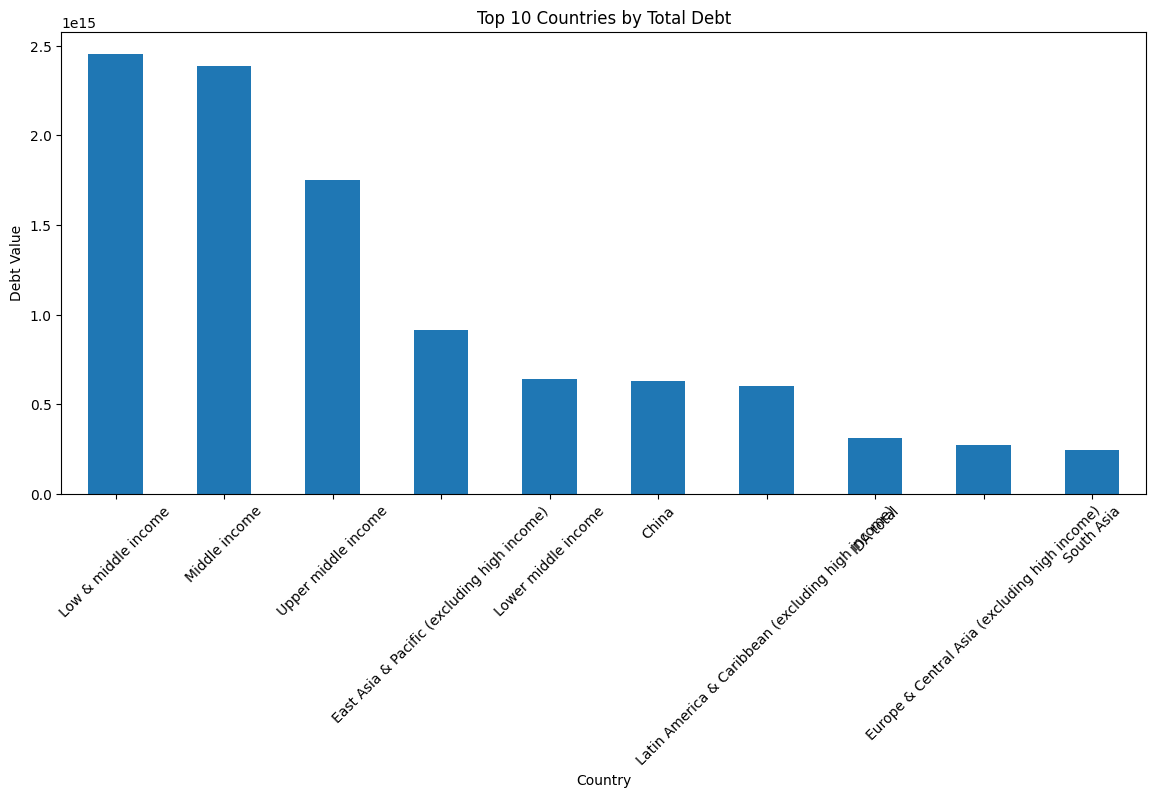

In [138]:
# 1. COUNTRY-WISE DEBT DISTRIBUTION
# =========================================================

country_debt = merged_df.groupby('country_name')['value'].sum().sort_values(ascending=False)

print(country_debt.head(10))

plt.figure(figsize=(14,6))

country_debt.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Total Debt')
plt.xlabel('Country')
plt.ylabel('Debt Value')

plt.xticks(rotation=45)

plt.show()


In [139]:
# 2. HIGHEST DEBT COUNTRIES
# =========================================================

highest_debt = merged_df.groupby('country_name')['value'].max().sort_values(ascending=False)

print("\nHighest Debt Countries")
print(highest_debt.head(10))



Highest Debt Countries
country_name
Low & middle income                                  3.820000e+13
Middle income                                        3.760000e+13
Upper middle income                                  2.990000e+13
East Asia & Pacific (excluding high income)          2.170000e+13
China                                                1.860000e+13
Lower middle income                                  7.770000e+12
Latin America & Caribbean (excluding high income)    5.800000e+12
South Asia                                           4.480000e+12
India                                                3.860000e+12
IDA total                                            2.850000e+12
Name: value, dtype: float64


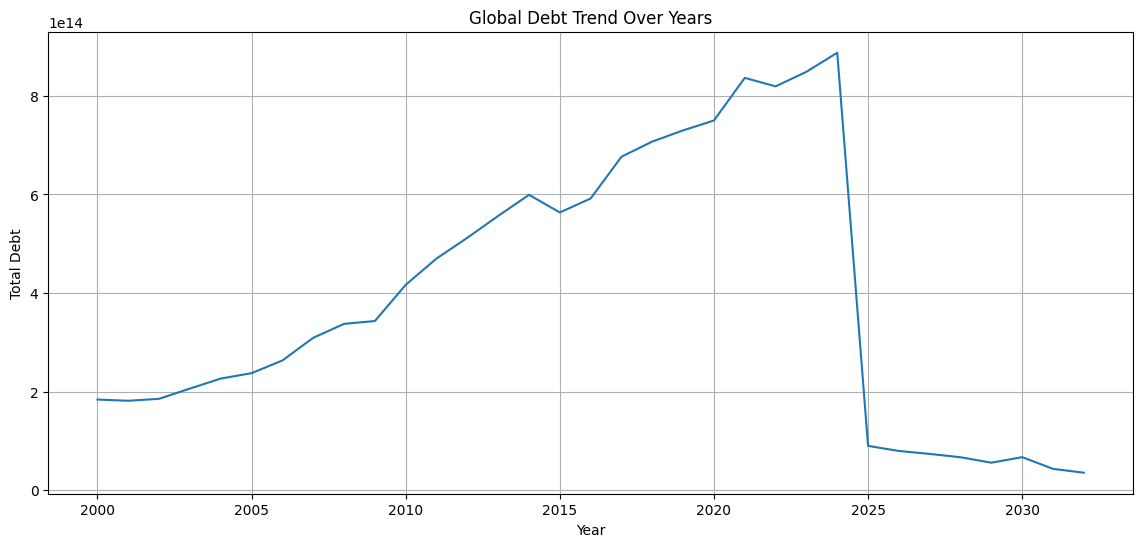

In [140]:
# 3. TREND ANALYSIS OVER YEARS
# =========================================================

yearly_trend = merged_df.groupby('year')['value'].sum()

plt.figure(figsize=(14,6))

plt.plot(yearly_trend.index, yearly_trend.values)

plt.title('Global Debt Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total Debt')

plt.grid(True)

plt.show()

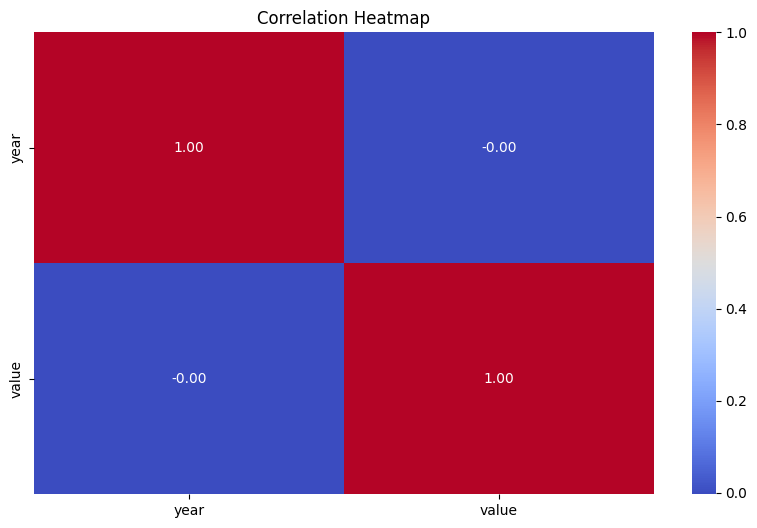

In [141]:
# 4. CORRELATION HEATMAP
# =========================================================

numeric_df = merged_df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()


In [142]:
print(meta.columns.tolist())

['country code', 'long name', 'income group', 'region', 'lending category', 'other groups', 'currency unit', 'latest population census', 'latest household survey', 'special notes', 'national accounts base year', 'national accounts reference year', 'system of national accounts', 'sna price valuation', 'ppp survey years', 'balance of payments manual in use', 'external debt reporting status', 'system of trade', 'government accounting concept', 'imf data dissemination standard', 'source of most recent income and expenditure data', 'vital registration complete', 'latest agricultural census', 'latest industrial data', 'latest trade data', 'latest water withdrawal data', '2-alpha code', 'wb-2 code', 'country name', 'short name']


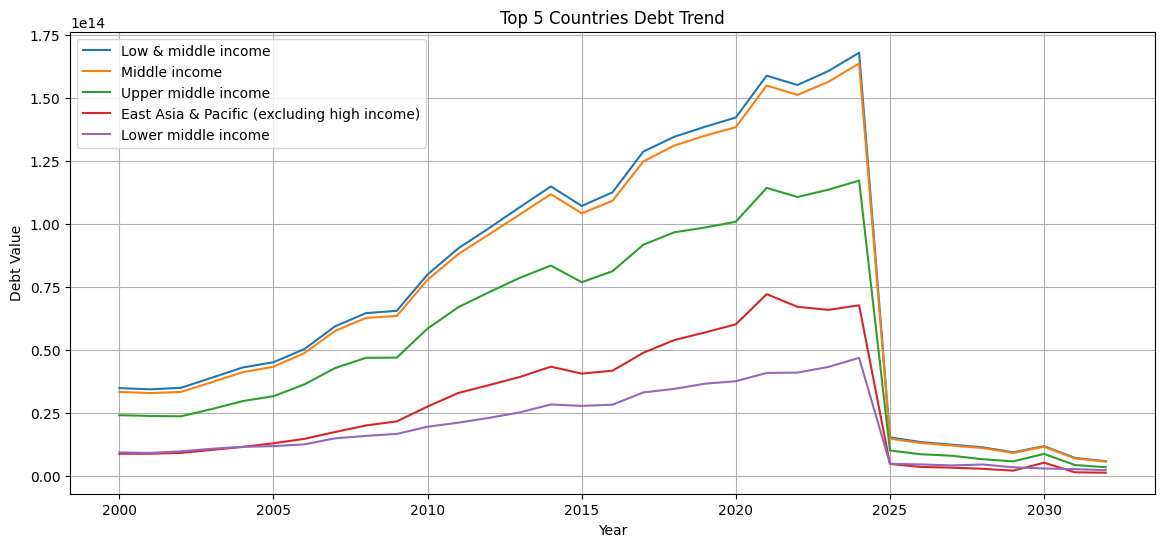

In [143]:
# TOP 5 COUNTRIES TREND ANALYSIS
# =========================================================

top5 = country_debt.head(5).index

top5_data = merged_df[merged_df['country_name'].isin(top5)]

plt.figure(figsize=(14,6))

for country in top5:
    
    temp = top5_data[top5_data['country_name'] == country]
    
    yearly = temp.groupby('year')['value'].sum()
    
    plt.plot(yearly.index, yearly.values, label=country)

plt.title('Top 5 Countries Debt Trend')
plt.xlabel('Year')
plt.ylabel('Debt Value')

plt.legend()

plt.grid(True)

plt.show()